# 手写数字识别提交版 Notebook

本 notebook 用于提交《AI 导论》手写数字识别作业，目标是在 0-9 共 10 类手写数字 / 类 MNIST 28×28 灰度图任务上训练一个更稳健的 CNN 分类器。

当前版本保留原有 MNIST baseline、`SmallCNN`、训练/验证、预测导出和 Optuna HPO 流程，并新增 EMNIST Digits、USPS、可选 QMNIST 外部数据集支持、mixed validation、统一私有图片预处理、Early Stopping、学习率调度器、TTA 推理和“考试模式”。默认训练使用更强的 `MediumCNN`、大 batch、AdamW、label smoothing、CUDA AMP、TF32 和 cuDNN benchmark，以提高吞吐并改善 GPU 利用率；普通训练可在 MNIST-only 验证与 mixed 跨来源验证之间切换，考试模式默认关闭。

## 1. 运行说明与提交说明

请在 VS Code 或 Jupyter 中从上到下顺序运行所有单元格。普通训练由配置单元控制：`RUN_HPO` 决定是否先进行 Optuna 调参，`EXAM_MODE` 决定是否进入考试模式，`VALIDATION_SOURCE` 决定使用 mixed 跨来源验证还是 MNIST-only 验证。运行完成后，notebook 会生成以下内容：

- 数据集基本信息、外部数据集来源和样例图片；
- CNN 模型结构与参数量；
- 训练集 / 验证集 loss、accuracy 和 learning rate 曲线；
- 验证集准确率、分类报告和混淆矩阵；
- 误分类样例分析；
- `outputs_submission/` 目录中的模型权重、训练记录、HPO 记录、实验摘要和预测 CSV。

如果只想快速跑通流程，可以把配置单元中的 `RUN_HPO` 改为 `False`，并关闭 USPS / QMNIST。 如果老师现场提供图片或少量有标签数据，可以把 `EXAM_MODE` 改为 `True` 使用考试模式。中文显示方面：notebook 文件使用 UTF-8 编码，CSV 使用 `utf-8-sig` 编码，matplotlib 会优先选择 Windows 常见中文字体。

## 2. 导入依赖与全局配置

这一部分导入 PyTorch、torchvision、matplotlib、scikit-learn 等依赖，并固定随机种子，保证实验尽量可复现。

In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

import csv
import json
import math
import random
import sys
import time
from contextlib import nullcontext
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
from torch import nn
from torch.utils.data import ConcatDataset, DataLoader, Dataset, Subset
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF

try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

def configure_chinese_display():
    candidates = ["Microsoft YaHei", "SimHei", "SimSun", "Noto Sans CJK SC", "WenQuanYi Micro Hei"]
    available = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available:
            plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
            break
    else:
        plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
        print("提示：当前环境没有检测到常见中文字体，图表中文可能显示为方框。")
    plt.rcParams["axes.unicode_minus"] = False

configure_chinese_display()

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs_submission"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"
PREDICTION_DIR = OUTPUT_DIR / "predictions"
HPO_DIR = OUTPUT_DIR / "hpo"

for path_item in [DATA_DIR, CHECKPOINT_DIR, FIGURE_DIR, LOG_DIR, PREDICTION_DIR, HPO_DIR]:
    path_item.mkdir(parents=True, exist_ok=True)

SEED = 42
MODEL_NAME = "medium_cnn"
BATCH_SIZE = 1024
VALIDATION_SPLIT = 0.2
IMAGE_SIZE = 28
NUM_CLASSES = 10
LEARNING_RATE = 1e-3
EPOCHS = 40
NUM_WORKERS = 8
WEIGHT_DECAY = 1e-4
DROPOUT = 0.30
LABEL_SMOOTHING = 0.03

USE_MNIST = True
USE_EMNIST_DIGITS = True
USE_USPS = True
USE_QMNIST = True
EMNIST_MAX_SAMPLES = 50000
USPS_MAX_SAMPLES = None
QMNIST_MAX_SAMPLES = 60000
VALIDATION_SOURCE = "mixed"
USE_EXTERNAL_28X28_HOLDOUTS = True
EXTERNAL_HOLDOUT_NAMES = ["mnist_test", "emnist_digits_test", "qmnist_test10k"]
EXTERNAL_VALIDATION_BATCH_SIZE = 512

ROTATION_DEGREES = 10
TRANSLATE_RATIO = 0.08
SCALE_MIN = 0.90
SCALE_MAX = 1.10
SHEAR_DEGREES = 4
USE_RANDOM_AFFINE = True
USE_GAUSSIAN_BLUR = False

RUN_HPO = True
APPLY_BEST_HPO_PARAMS = True
HPO_N_TRIALS = 20
HPO_EPOCHS = 5
HPO_VALIDATION_SPLIT = 0.15

USE_EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 7
EARLY_STOPPING_MIN_DELTA = 1e-4
SCHEDULER_TYPE = "ReduceLROnPlateau"
OPTIMIZER_TYPE = "AdamW"

EXAM_MODE = False
EXAM_DATA_DIR = "exam_data"
EXAM_TRAIN_DIR = "exam_data/train"
EXAM_TEST_DIR = "exam_data/test"
EXAM_OUTPUT_CSV = "outputs_submission/predictions/exam_predictions.csv"
EXAM_USE_PRETRAINED_CHECKPOINT = True
EXAM_CHECKPOINT_PATH = "outputs_submission/checkpoints/best_model_state.pt"
EXAM_FAST_HPO = True
EXAM_HPO_N_TRIALS = 5
EXAM_HPO_EPOCHS = 2
EXAM_FINE_TUNE_EPOCHS = 3
EXAM_FINE_TUNE_LR = 3e-4
EXAM_FREEZE_FEATURE_EXTRACTOR = False
USE_TTA = True
TTA_N = 8
LOW_CONFIDENCE_THRESHOLD = 0.70

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE == "cuda"
ALLOW_TF32 = DEVICE == "cuda"
PIN_MEMORY = DEVICE == "cuda"
PERSISTENT_WORKERS = True
PREFETCH_FACTOR = 2
DATALOADER_TIMEOUT = 60
STRICT_REPRODUCIBILITY = False
NORMALIZE_MEAN = (0.5,)
NORMALIZE_STD = (0.5,)
SUPPORTED_IMAGE_SUFFIXES = {".png", ".jpg", ".jpeg", ".bmp"}

def configure_torch_backend(strict_reproducibility: bool, allow_tf32: bool):
    torch.backends.cudnn.benchmark = not strict_reproducibility
    torch.backends.cudnn.deterministic = strict_reproducibility
    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = allow_tf32
        torch.backends.cudnn.allow_tf32 = allow_tf32
    if allow_tf32 and hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")

def set_seed(seed: int, strict_reproducibility: bool = STRICT_REPRODUCIBILITY, allow_tf32: bool = ALLOW_TF32):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    configure_torch_backend(strict_reproducibility, allow_tf32)

set_seed(SEED)
print(f"当前项目目录：{PROJECT_ROOT}")
print(f"使用设备：{DEVICE}")
print(f"模型默认配置：MODEL_NAME={MODEL_NAME}, BATCH_SIZE={BATCH_SIZE}, NUM_WORKERS={NUM_WORKERS}")
print(f"CUDA 加速：USE_AMP={USE_AMP}, ALLOW_TF32={ALLOW_TF32}, cuDNN benchmark={torch.backends.cudnn.benchmark}")
print(f"所有输出将保存到：{OUTPUT_DIR}")

当前项目目录：e:\ALL\学习\AI导论作业-识别手写数字
使用设备：cuda
模型默认配置：MODEL_NAME=medium_cnn, BATCH_SIZE=1024, NUM_WORKERS=8
CUDA 加速：USE_AMP=True, ALLOW_TF32=True, cuDNN benchmark=True
所有输出将保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission


## 3. 实验配置

为了让实验参数清晰可追踪，这里把数据路径、训练轮数、批大小、学习率等参数集中保存。后面保存训练日志时，也会把这些配置写入 JSON 文件。

In [2]:
@dataclass
class ExperimentConfig:
    project_root: Path = PROJECT_ROOT
    data_dir: Path = DATA_DIR
    output_dir: Path = OUTPUT_DIR
    model_name: str = MODEL_NAME
    batch_size: int = BATCH_SIZE
    validation_split: float = VALIDATION_SPLIT
    image_size: int = IMAGE_SIZE
    num_classes: int = NUM_CLASSES
    in_channels: int = 1
    learning_rate: float = LEARNING_RATE
    epochs: int = EPOCHS
    seed: int = SEED
    num_workers: int = NUM_WORKERS
    pin_memory: bool = PIN_MEMORY
    persistent_workers: bool = PERSISTENT_WORKERS
    prefetch_factor: int | None = PREFETCH_FACTOR
    dataloader_timeout: int = DATALOADER_TIMEOUT
    weight_decay: float = WEIGHT_DECAY
    dropout: float = DROPOUT
    label_smoothing: float = LABEL_SMOOTHING
    optimizer_type: str = OPTIMIZER_TYPE
    scheduler_type: str = SCHEDULER_TYPE
    use_amp: bool = USE_AMP
    allow_tf32: bool = ALLOW_TF32
    strict_reproducibility: bool = STRICT_REPRODUCIBILITY
    rotation_degrees: float = ROTATION_DEGREES
    translate_ratio: float = TRANSLATE_RATIO
    scale_min: float = SCALE_MIN
    scale_max: float = SCALE_MAX
    shear_degrees: float = SHEAR_DEGREES
    use_random_affine: bool = USE_RANDOM_AFFINE
    use_gaussian_blur: bool = USE_GAUSSIAN_BLUR
    use_mnist: bool = USE_MNIST
    use_emnist_digits: bool = USE_EMNIST_DIGITS
    use_usps: bool = USE_USPS
    use_qmnist: bool = USE_QMNIST
    emnist_max_samples: int | None = EMNIST_MAX_SAMPLES
    usps_max_samples: int | None = USPS_MAX_SAMPLES
    qmnist_max_samples: int | None = QMNIST_MAX_SAMPLES
    validation_source: str = VALIDATION_SOURCE
    use_external_28x28_holdouts: bool = USE_EXTERNAL_28X28_HOLDOUTS
    external_holdout_names: list[str] | None = None
    external_validation_batch_size: int = EXTERNAL_VALIDATION_BATCH_SIZE
    use_early_stopping: bool = USE_EARLY_STOPPING
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE
    early_stopping_min_delta: float = EARLY_STOPPING_MIN_DELTA
    use_tta: bool = USE_TTA
    tta_n: int = TTA_N

    def __post_init__(self):
        if self.external_holdout_names is None:
            self.external_holdout_names = list(EXTERNAL_HOLDOUT_NAMES)

    def to_dict(self) -> dict:
        payload = asdict(self)
        for key, value in payload.items():
            if isinstance(value, Path):
                payload[key] = str(value)
        return payload

config = ExperimentConfig()
print(json.dumps(config.to_dict(), ensure_ascii=False, indent=2))

{
  "project_root": "e:\\ALL\\学习\\AI导论作业-识别手写数字",
  "data_dir": "e:\\ALL\\学习\\AI导论作业-识别手写数字\\data",
  "output_dir": "e:\\ALL\\学习\\AI导论作业-识别手写数字\\outputs_submission",
  "model_name": "medium_cnn",
  "batch_size": 1024,
  "validation_split": 0.2,
  "image_size": 28,
  "num_classes": 10,
  "in_channels": 1,
  "learning_rate": 0.001,
  "epochs": 40,
  "seed": 42,
  "num_workers": 8,
  "pin_memory": true,
  "persistent_workers": true,
  "prefetch_factor": 2,
  "dataloader_timeout": 60,
  "weight_decay": 0.0001,
  "dropout": 0.3,
  "label_smoothing": 0.03,
  "optimizer_type": "AdamW",
  "scheduler_type": "ReduceLROnPlateau",
  "use_amp": true,
  "allow_tf32": true,
  "strict_reproducibility": false,
  "rotation_degrees": 10,
  "translate_ratio": 0.08,
  "scale_min": 0.9,
  "scale_max": 1.1,
  "shear_degrees": 4,
  "use_random_affine": true,
  "use_gaussian_blur": false,
  "use_mnist": true,
  "use_emnist_digits": true,
  "use_usps": true,
  "use_qmnist": true,
  "emnist_max_samples": 50000,


## 4. 数据读取、外部数据集与统一预处理

默认训练仍保留 MNIST baseline，并可通过配置把 EMNIST Digits、USPS、QMNIST 合并到训练集中。外部数据集会统一转换为单通道灰度、28×28、标签 0-9、MNIST 风格 Tensor。

`VALIDATION_SOURCE` 支持两种模式：

- `"mixed"`：每个已开启数据源都会按 `VALIDATION_SPLIT` 固定切分，验证集由 MNIST / EMNIST Digits / USPS / QMNIST 的验证子集共同组成，更适合观察跨数据源泛化能力；
- `"mnist_validation"`：只从 MNIST 切出验证集，外部数据全部用于训练，适合和原始 MNIST baseline 做清晰对比。

训练集使用轻量随机仿射增强（旋转、平移、缩放、shear），用于提升模型对非 MNIST 来源手写数字的泛化能力。验证集、测试集和考试预测只做确定性预处理，不使用随机增强。

In [3]:
def build_transforms(
    image_size: int,
    rotation_degrees: float,
    translate_ratio: float,
    scale_min: float = 1.0,
    scale_max: float = 1.0,
    shear_degrees: float = 0.0,
    use_random_affine: bool = True,
    use_gaussian_blur: bool = False,
):
    base_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((image_size, image_size), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ])

    train_steps = [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((image_size, image_size), interpolation=InterpolationMode.BILINEAR),
    ]
    if use_random_affine:
        train_steps.append(
            transforms.RandomAffine(
                degrees=rotation_degrees,
                translate=(translate_ratio, translate_ratio),
                scale=(scale_min, scale_max),
                shear=(-shear_degrees, shear_degrees),
                interpolation=InterpolationMode.BILINEAR,
                fill=0,
            )
        )
    if use_gaussian_blur:
        train_steps.append(transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))], p=0.25))
    train_steps.extend([transforms.ToTensor(), transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD)])
    train_transform = transforms.Compose(train_steps)
    return base_transform, train_transform

def build_emnist_orientation_transform():
    return transforms.Compose([
        transforms.RandomRotation(degrees=(-90, -90), interpolation=InterpolationMode.BILINEAR, fill=0),
        transforms.RandomHorizontalFlip(p=1.0),
    ])

def sample_subset(dataset, max_samples: int | None, seed: int):
    if max_samples is None or max_samples >= len(dataset):
        return dataset
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:max_samples].tolist()
    return Subset(dataset, indices)

def sample_dataset_pair(base_dataset, augmented_dataset, max_samples: int | None, seed: int):
    if max_samples is None or max_samples >= len(base_dataset):
        return base_dataset, augmented_dataset
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(base_dataset), generator=generator)[:max_samples].tolist()
    return Subset(base_dataset, indices), Subset(augmented_dataset, indices)

def split_dataset_indices(dataset_size: int, validation_split: float, seed: int):
    if not 0 < validation_split < 1:
        raise ValueError("VALIDATION_SPLIT 必须在 0 和 1 之间。")
    val_size = max(1, int(dataset_size * validation_split))
    train_size = dataset_size - val_size
    if train_size <= 0:
        raise ValueError("验证集比例过大，导致训练样本数为 0。")
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(dataset_size, generator=generator).tolist()
    return indices[:train_size], indices[train_size:]

def get_subset_targets(dataset) -> np.ndarray:
    if isinstance(dataset, Subset):
        base_targets = get_subset_targets(dataset.dataset)
        return np.asarray(base_targets)[dataset.indices]
    if hasattr(dataset, "targets"):
        targets = dataset.targets
        return targets.numpy() if torch.is_tensor(targets) else np.asarray(targets)
    if hasattr(dataset, "labels"):
        labels = dataset.labels
        return labels.numpy() if torch.is_tensor(labels) else np.asarray(labels)
    return np.asarray([dataset[i][1] for i in range(len(dataset))])

def build_source_dataset_pairs(base_transform, train_transform, cfg: ExperimentConfig):
    source_pairs = []

    if cfg.use_mnist:
        mnist_base = datasets.MNIST(root=str(cfg.data_dir), train=True, download=True, transform=base_transform)
        mnist_augmented = datasets.MNIST(root=str(cfg.data_dir), train=True, download=True, transform=train_transform)
        source_pairs.append(("MNIST", mnist_base, mnist_augmented, cfg.seed))

    if cfg.use_emnist_digits:
        emnist_base_transform = transforms.Compose([build_emnist_orientation_transform(), base_transform])
        emnist_train_transform = transforms.Compose([build_emnist_orientation_transform(), train_transform])
        emnist_base = datasets.EMNIST(root=str(cfg.data_dir), split="digits", train=True, download=True, transform=emnist_base_transform)
        emnist_augmented = datasets.EMNIST(root=str(cfg.data_dir), split="digits", train=True, download=True, transform=emnist_train_transform)
        emnist_base, emnist_augmented = sample_dataset_pair(emnist_base, emnist_augmented, cfg.emnist_max_samples, cfg.seed + 11)
        source_pairs.append(("EMNIST Digits", emnist_base, emnist_augmented, cfg.seed + 11))

    if cfg.use_usps:
        usps_base = datasets.USPS(root=str(cfg.data_dir), train=True, download=True, transform=base_transform)
        usps_augmented = datasets.USPS(root=str(cfg.data_dir), train=True, download=True, transform=train_transform)
        usps_base, usps_augmented = sample_dataset_pair(usps_base, usps_augmented, cfg.usps_max_samples, cfg.seed + 21)
        source_pairs.append(("USPS", usps_base, usps_augmented, cfg.seed + 21))

    if cfg.use_qmnist:
        qmnist_base = datasets.QMNIST(root=str(cfg.data_dir), what="train", download=True, transform=base_transform)
        qmnist_augmented = datasets.QMNIST(root=str(cfg.data_dir), what="train", download=True, transform=train_transform)
        qmnist_base, qmnist_augmented = sample_dataset_pair(qmnist_base, qmnist_augmented, cfg.qmnist_max_samples, cfg.seed + 31)
        source_pairs.append(("QMNIST", qmnist_base, qmnist_augmented, cfg.seed + 31))

    return source_pairs

def concat_source_datasets(sources):
    datasets_only = [dataset for _, dataset in sources]
    return datasets_only[0] if len(datasets_only) == 1 else ConcatDataset(datasets_only)

def load_training_sources(base_transform, train_transform, cfg: ExperimentConfig):
    validation_mode = cfg.validation_source.lower()
    if validation_mode not in {"mixed", "mnist_validation"}:
        raise ValueError('VALIDATION_SOURCE 只能设置为 "mixed" 或 "mnist_validation"。')

    train_sources = []
    val_sources = []
    preview_sources = {}
    source_sizes = {}
    source_splits = {}
    source_pairs = build_source_dataset_pairs(base_transform, train_transform, cfg)

    if not source_pairs:
        raise ValueError("至少需要开启一个训练数据集，例如 USE_MNIST=True。")

    for source_name, base_dataset, augmented_dataset, split_seed in source_pairs:
        preview_sources[source_name] = base_dataset

        if validation_mode == "mnist_validation" and source_name != "MNIST":
            train_indices_for_source = list(range(len(augmented_dataset)))
            val_indices_for_source = []
            train_dataset_for_source = augmented_dataset
            val_dataset_for_source = None
        else:
            train_indices_for_source, val_indices_for_source = split_dataset_indices(
                len(base_dataset), cfg.validation_split, split_seed
            )
            train_dataset_for_source = Subset(augmented_dataset, train_indices_for_source)
            val_dataset_for_source = Subset(base_dataset, val_indices_for_source)
            val_sources.append((source_name, val_dataset_for_source))

        train_sources.append((source_name, train_dataset_for_source))
        source_sizes[source_name] = {
            "train": len(train_dataset_for_source),
            "validation": 0 if val_dataset_for_source is None else len(val_dataset_for_source),
        }
        source_splits[source_name] = {
            "train_indices": train_indices_for_source,
            "val_indices": val_indices_for_source,
            "split_seed": split_seed,
        }

    if not val_sources:
        raise ValueError('VALIDATION_SOURCE="mnist_validation" 需要 USE_MNIST=True；否则请改用 VALIDATION_SOURCE="mixed"。')

    train_dataset = concat_source_datasets(train_sources)
    val_dataset = concat_source_datasets(val_sources)
    return train_dataset, val_dataset, preview_sources, source_sizes, source_splits

def make_data_loaders(
    train_dataset,
    val_dataset,
    batch_size: int,
    seed: int,
    num_workers: int = 0,
    pin_memory: bool = False,
    persistent_workers: bool = False,
    prefetch_factor: int | None = None,
    dataloader_timeout: int = 0,
):
    train_generator = torch.Generator().manual_seed(seed)
    loader_kwargs = {
        "num_workers": int(num_workers),
        "pin_memory": bool(pin_memory),
    }
    if num_workers > 0:
        loader_kwargs["persistent_workers"] = bool(persistent_workers)
        loader_kwargs["multiprocessing_context"] = "spawn"
        if dataloader_timeout > 0:
            loader_kwargs["timeout"] = int(dataloader_timeout)
        if prefetch_factor is not None:
            loader_kwargs["prefetch_factor"] = int(prefetch_factor)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=train_generator,
        **loader_kwargs,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        **loader_kwargs,
    )
    return train_loader, val_loader

def shutdown_data_loader_workers(loader):
    iterator = getattr(loader, "_iterator", None)
    if iterator is not None and hasattr(iterator, "_shutdown_workers"):
        iterator._shutdown_workers()
        loader._iterator = None

def shutdown_existing_data_loaders():
    for loader_name in ("train_loader", "val_loader"):
        loader = globals().get(loader_name)
        if loader is not None:
            shutdown_data_loader_workers(loader)

shutdown_existing_data_loaders()

base_transform, train_transform = build_transforms(
    image_size=config.image_size,
    rotation_degrees=config.rotation_degrees,
    translate_ratio=config.translate_ratio,
    scale_min=config.scale_min,
    scale_max=config.scale_max,
    shear_degrees=config.shear_degrees,
    use_random_affine=config.use_random_affine,
    use_gaussian_blur=config.use_gaussian_blur,
)
train_dataset, val_dataset, preview_sources, source_sizes, source_splits = load_training_sources(base_transform, train_transform, config)
train_loader, val_loader = make_data_loaders(
    train_dataset,
    val_dataset,
    config.batch_size,
    config.seed,
    config.num_workers,
    pin_memory=config.pin_memory,
    persistent_workers=config.persistent_workers,
    prefetch_factor=config.prefetch_factor,
    dataloader_timeout=config.dataloader_timeout,
)
primary_source_name, mnist_dataset = next(iter(preview_sources.items()))

print("训练 / 验证数据来源：")
for source_name, sizes in source_sizes.items():
    print(f"- {source_name}: 训练 {sizes['train']} 张，验证 {sizes['validation']} 张")
print(f"合并训练集样本数：{len(train_dataset)}")
print(f"合并验证集样本数：{len(val_dataset)}")
print(f"验证集模式：{config.validation_source}")
print(
    "DataLoader："
    f"batch_size={config.batch_size}, num_workers={config.num_workers}, "
    f"pin_memory={config.pin_memory}, persistent_workers={config.persistent_workers if config.num_workers > 0 else False}, "
    f"prefetch_factor={config.prefetch_factor if config.num_workers > 0 else None}, "
    f"timeout={config.dataloader_timeout if config.num_workers > 0 else 0}"
)
if sys.platform.startswith("win") and config.num_workers > 0:
    print("提示：Windows + VS Code/Jupyter 如卡在 batch 预览或训练第一步，可把 NUM_WORKERS 改为 0 后重跑本单元。")
print(
    "训练增强："
    f"旋转 ±{config.rotation_degrees}°，平移 {config.translate_ratio:.2f}，"
    f"缩放 {config.scale_min:.2f}-{config.scale_max:.2f}，shear ±{config.shear_degrees}°"
)

训练 / 验证数据来源：
- MNIST: 训练 48000 张，验证 12000 张
- EMNIST Digits: 训练 40000 张，验证 10000 张
- USPS: 训练 5833 张，验证 1458 张
- QMNIST: 训练 48000 张，验证 12000 张
合并训练集样本数：141833
合并验证集样本数：35458
验证集模式：mixed
DataLoader：batch_size=1024, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=2, timeout=60
提示：Windows + VS Code/Jupyter 如卡在 batch 预览或训练第一步，可把 NUM_WORKERS 改为 0 后重跑本单元。
训练增强：旋转 ±10°，平移 0.08，缩放 0.90-1.10，shear ±4°


In [4]:
def _auto_invert_grayscale(gray: Image.Image, invert: str | bool = "auto") -> Image.Image:
    if invert is True or invert == "yes":
        return ImageOps.invert(gray)
    if invert is False or invert == "no":
        return gray
    pixels = np.asarray(gray, dtype=np.uint8)
    border = np.concatenate([pixels[0, :], pixels[-1, :], pixels[:, 0], pixels[:, -1]])
    background_is_light = float(np.median(border)) > 127
    return ImageOps.invert(gray) if background_is_light else gray

def _crop_digit_foreground(gray_black_bg: Image.Image, threshold: int = 20) -> Image.Image:
    array = np.asarray(gray_black_bg, dtype=np.uint8)
    mask = array > threshold
    if not mask.any():
        return gray_black_bg
    ys, xs = np.where(mask)
    top, bottom = int(ys.min()), int(ys.max()) + 1
    left, right = int(xs.min()), int(xs.max()) + 1
    pad = max(2, int(0.08 * max(bottom - top, right - left)))
    top = max(0, top - pad)
    left = max(0, left - pad)
    bottom = min(array.shape[0], bottom + pad)
    right = min(array.shape[1], right + pad)
    return gray_black_bg.crop((left, top, right, bottom))

def _resize_and_center(gray_black_bg: Image.Image, image_size: int = 28, target_size: int = 22) -> Image.Image:
    width, height = gray_black_bg.size
    if width == 0 or height == 0:
        return Image.new("L", (image_size, image_size), color=0)
    scale = target_size / max(width, height)
    new_size = (max(1, int(round(width * scale))), max(1, int(round(height * scale))))
    resized = gray_black_bg.resize(new_size, resample=Image.Resampling.LANCZOS)
    canvas = Image.new("L", (image_size, image_size), color=0)
    left = (image_size - new_size[0]) // 2
    top = (image_size - new_size[1]) // 2
    canvas.paste(resized, (left, top))
    return canvas

def preprocess_digit_pil(image: Image.Image, image_size: int = 28, invert: str | bool = "auto", return_steps: bool = False):
    original = image.copy()
    gray = ImageOps.exif_transpose(image).convert("L")
    inverted = _auto_invert_grayscale(gray, invert=invert)
    cropped = _crop_digit_foreground(inverted)
    final_image = _resize_and_center(cropped, image_size=image_size, target_size=22)
    tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ])(final_image)
    if return_steps:
        return tensor, {"original": original, "gray": gray, "processed": cropped, "final": final_image}
    return tensor

def preprocess_digit_image(image_path, image_size: int = 28, invert: str | bool = "auto") -> torch.Tensor:
    with Image.open(image_path) as image:
        return preprocess_digit_pil(image, image_size=image_size, invert=invert, return_steps=False)

def visualize_preprocessing(image_path, invert: str | bool = "auto"):
    with Image.open(image_path) as image:
        tensor, steps = preprocess_digit_pil(image, image_size=config.image_size, invert=invert, return_steps=True)
    titles = ["原图", "灰度图", "反色/裁剪后", "最终 28×28 输入"]
    images = [steps["original"], steps["gray"], steps["processed"], steps["final"]]
    fig, axes = plt.subplots(1, 4, figsize=(10, 3))
    for axis, title, image in zip(axes, titles, images):
        axis.imshow(image, cmap="gray")
        axis.set_title(title)
        axis.axis("off")
    fig.tight_layout()
    plt.show()
    print(f"最终 Tensor 形状：{tuple(tensor.shape)}，数值范围：{tensor.min().item():.3f} 到 {tensor.max().item():.3f}")
    return tensor

class PreprocessedImageDataset(Dataset):
    def __init__(self, image_paths, labels=None, image_size: int = 28):
        self.image_paths = [Path(path) for path in image_paths]
        self.labels = labels
        self.image_size = image_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        tensor = preprocess_digit_image(self.image_paths[index], image_size=self.image_size, invert="auto")
        if self.labels is None:
            return tensor, self.image_paths[index].name
        return tensor, int(self.labels[index])

print("已定义 preprocess_digit_image(image_path, image_size=28, invert='auto') 和 visualize_preprocessing(image_path)。")

已定义 preprocess_digit_image(image_path, image_size=28, invert='auto') 和 visualize_preprocessing(image_path)。


## 5. 数据集初步观察

训练前先检查类别分布和样例图片。这样可以确认数据是否成功读取，也能直观看到手写数字存在笔画粗细、倾斜角度和书写风格差异。

,数字类别,样本数量
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


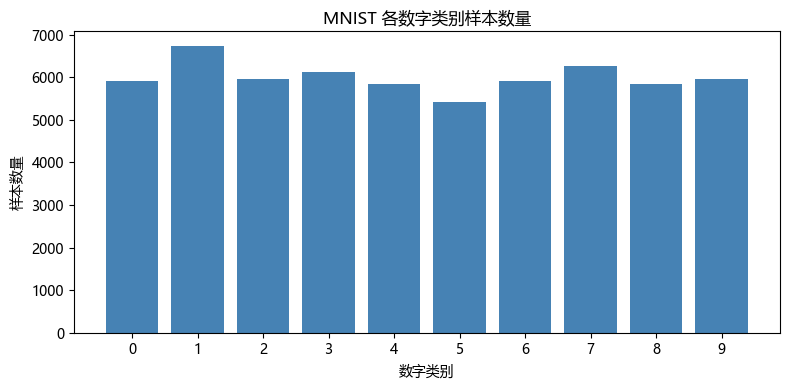

In [5]:
targets = get_subset_targets(mnist_dataset)
class_counts = np.bincount(targets.astype(int), minlength=config.num_classes)
distribution = pd.DataFrame({"数字类别": list(range(config.num_classes)), "样本数量": class_counts})
display(distribution)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(distribution["数字类别"], distribution["样本数量"], color="steelblue")
ax.set_title(f"{primary_source_name} 各数字类别样本数量")
ax.set_xlabel("数字类别")
ax.set_ylabel("样本数量")
ax.set_xticks(range(config.num_classes))
fig.tight_layout()
plt.show()

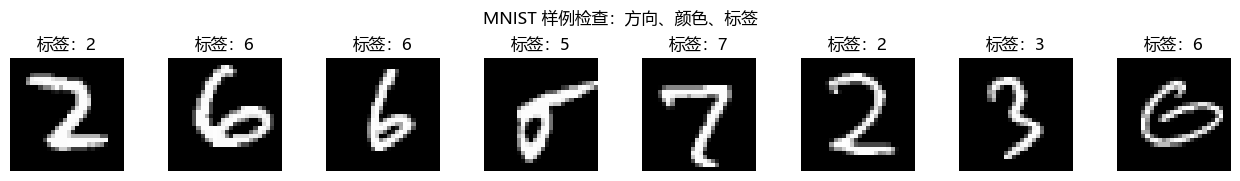

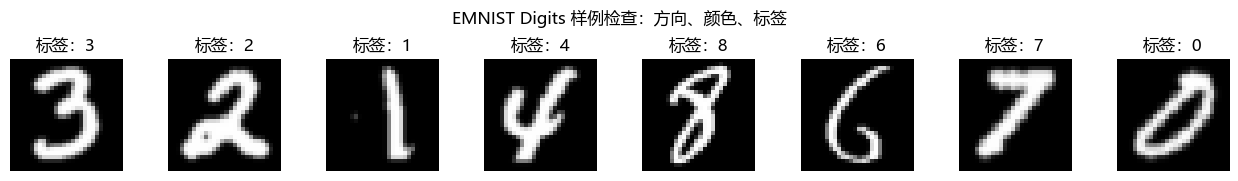

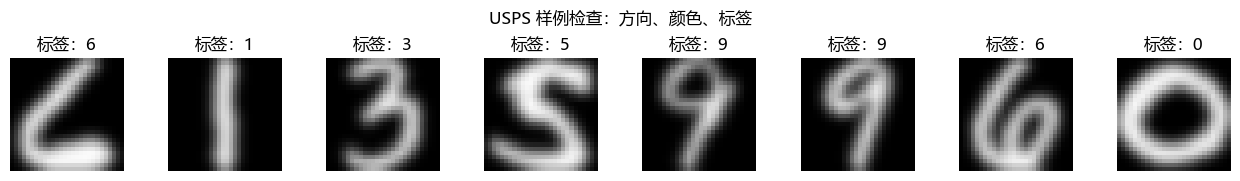

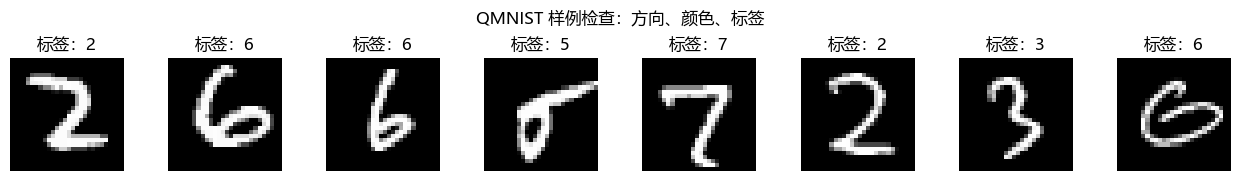

Batch preview DataLoader 设置：num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=2, timeout=60
如果本单元卡住，通常是 Windows/Jupyter DataLoader 多进程启动问题；把 NUM_WORKERS 改为 0 后重跑数据加载单元即可。
一个 batch 的图片形状：(1024, 1, 28, 28)
一个 batch 的标签形状：(1024,)


In [6]:
def denormalize_digit_tensor(image: torch.Tensor) -> np.ndarray:
    return (image * NORMALIZE_STD[0] + NORMALIZE_MEAN[0]).clamp(0, 1).squeeze(0).numpy()

def show_image_grid(dataset, rows: int = 2, cols: int = 5, title: str = "手写数字样例"):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.8))
    axes = np.array(axes).reshape(rows, cols)
    sample_count = min(rows * cols, len(dataset))
    indices = np.random.default_rng(config.seed).choice(len(dataset), size=sample_count, replace=False)
    for axis, index in zip(axes.ravel(), indices):
        image, label = dataset[int(index)]
        axis.imshow(denormalize_digit_tensor(image), cmap="gray", vmin=0, vmax=1)
        axis.set_title(f"标签：{int(label)}")
        axis.axis("off")
    for axis in axes.ravel()[sample_count:]:
        axis.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

def visualize_dataset_sources(preview_sources: dict[str, Dataset], rows: int = 1, cols: int = 8):
    for source_name, dataset in preview_sources.items():
        show_image_grid(dataset, rows=rows, cols=cols, title=f"{source_name} 样例检查：方向、颜色、标签")

visualize_dataset_sources(preview_sources)
print(
    "Batch preview DataLoader 设置："
    f"num_workers={config.num_workers}, pin_memory={config.pin_memory}, "
    f"persistent_workers={config.persistent_workers if config.num_workers > 0 else False}, "
    f"prefetch_factor={config.prefetch_factor if config.num_workers > 0 else None}, "
    f"timeout={config.dataloader_timeout if config.num_workers > 0 else 0}"
)
if sys.platform.startswith("win") and config.num_workers > 0:
    print("如果本单元卡住，通常是 Windows/Jupyter DataLoader 多进程启动问题；把 NUM_WORKERS 改为 0 后重跑数据加载单元即可。")
try:
    batch_images, batch_labels = next(iter(train_loader))
except RuntimeError as error:
    print(f"DataLoader worker timeout or crash: {error}")
    print("Re-run the data loading cell first. The training pipeline now avoids notebook-local EMNIST transforms and uses spawn workers with timeout diagnostics.")
    raise
print(f"一个 batch 的图片形状：{tuple(batch_images.shape)}")
print(f"一个 batch 的标签形状：{tuple(batch_labels.shape)}")

## 6. 模型结构：SmallCNN 与 MediumCNN

本 notebook 保留原来的 `SmallCNN` 作为 baseline，同时新增默认的 `MediumCNN`：

- `SmallCNN` 适合快速调试和复现实验；
- `MediumCNN` 使用更多卷积层、更宽通道和 `AdaptiveAvgPool2d(1)`，在 28×28 灰度图任务上增加合理计算量，有助于提升泛化能力和 GPU 吞吐；
- `MODEL_NAME` 可在 `"small_cnn"` 与 `"medium_cnn"` 之间切换；
- 模型通过 `build_model(config)` 统一创建，训练、HPO、评估、TTA 和考试模式共用同一入口。

模型输出的是 logits，不是概率。训练时 `CrossEntropyLoss` 会自动完成 softmax 相关计算；预测展示时再用 softmax 转成概率。

In [7]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes: int = 10, in_channels: int = 1, dropout: float = 0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        features = self.features(inputs)
        return self.classifier(features)

class MediumCNN(nn.Module):
    def __init__(self, num_classes: int = 10, in_channels: int = 1, dropout: float = 0.30):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        features = self.features(inputs)
        return self.classifier(features)

def normalize_model_name(model_name: str) -> str:
    normalized = str(model_name).strip().lower().replace("-", "_")
    aliases = {
        "small": "small_cnn",
        "smallcnn": "small_cnn",
        "small_cnn": "small_cnn",
        "medium": "medium_cnn",
        "mediumcnn": "medium_cnn",
        "medium_cnn": "medium_cnn",
    }
    if normalized not in aliases:
        raise ValueError(f"不支持的 MODEL_NAME: {model_name}，可选 small_cnn / medium_cnn。")
    return aliases[normalized]

def build_model(config_or_name, num_classes: int | None = None, in_channels: int | None = None, dropout: float | None = None):
    if isinstance(config_or_name, ExperimentConfig):
        model_name = config_or_name.model_name
        num_classes = config_or_name.num_classes if num_classes is None else num_classes
        in_channels = config_or_name.in_channels if in_channels is None else in_channels
        dropout = config_or_name.dropout if dropout is None else dropout
    else:
        model_name = str(config_or_name)
        num_classes = config.num_classes if num_classes is None else num_classes
        in_channels = config.in_channels if in_channels is None else in_channels
        dropout = config.dropout if dropout is None else dropout

    normalized_name = normalize_model_name(model_name)
    if normalized_name == "small_cnn":
        return SmallCNN(num_classes=num_classes, in_channels=in_channels, dropout=dropout)
    return MediumCNN(num_classes=num_classes, in_channels=in_channels, dropout=dropout)

def count_model_parameters(model: nn.Module) -> tuple[int, int]:
    total_params = sum(parameter.numel() for parameter in model.parameters())
    trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return total_params, trainable_params

def make_autocast_context(cfg: ExperimentConfig, device: str = DEVICE):
    if device == "cuda" and cfg.use_amp:
        return torch.amp.autocast("cuda")
    return nullcontext()

def _checkpoint_state_dict(checkpoint_payload):
    if isinstance(checkpoint_payload, dict) and "model_state_dict" in checkpoint_payload:
        return checkpoint_payload["model_state_dict"]
    return checkpoint_payload

def _checkpoint_config_dict(checkpoint_payload) -> dict:
    if not isinstance(checkpoint_payload, dict):
        return {}
    checkpoint_config = checkpoint_payload.get("config", {})
    if isinstance(checkpoint_config, ExperimentConfig):
        return checkpoint_config.to_dict()
    return checkpoint_config if isinstance(checkpoint_config, dict) else {}

def _unique_model_candidates(*names):
    candidates = []
    for name in names:
        if not name:
            continue
        try:
            normalized_name = normalize_model_name(name)
        except ValueError:
            continue
        if normalized_name not in candidates:
            candidates.append(normalized_name)
    return candidates

def load_model_from_checkpoint(
    checkpoint: str | Path,
    cfg: ExperimentConfig | None = None,
    device: str = DEVICE,
    dropout: float | None = None,
    return_payload: bool = False,
):
    cfg = config if cfg is None else cfg
    checkpoint = Path(checkpoint)
    checkpoint_payload = torch.load(checkpoint, map_location=device)
    state_dict = _checkpoint_state_dict(checkpoint_payload)
    checkpoint_config = _checkpoint_config_dict(checkpoint_payload)
    checkpoint_model_name = checkpoint_payload.get("model_name") if isinstance(checkpoint_payload, dict) else None
    checkpoint_dropout = checkpoint_config.get("dropout") if isinstance(checkpoint_config, dict) else None
    model_dropout = dropout if dropout is not None else float(checkpoint_dropout if checkpoint_dropout is not None else cfg.dropout)
    candidates = _unique_model_candidates(
        checkpoint_model_name,
        checkpoint_config.get("model_name") if isinstance(checkpoint_config, dict) else None,
        cfg.model_name,
        "medium_cnn",
        "small_cnn",
    )
    last_error = None
    for model_name in candidates:
        candidate = build_model(
            model_name,
            num_classes=cfg.num_classes,
            in_channels=cfg.in_channels,
            dropout=model_dropout,
        ).to(device)
        try:
            candidate.load_state_dict(state_dict)
            candidate.eval()
            if return_payload:
                return candidate, checkpoint_payload, model_name
            return candidate
        except RuntimeError as error:
            last_error = error
    raise RuntimeError(f"无法用 small_cnn 或 medium_cnn 加载 checkpoint: {checkpoint}\n{last_error}")

model = build_model(config).to(DEVICE)
total_params, trainable_params = count_model_parameters(model)
print(model)
print(f"当前模型：{normalize_model_name(config.model_name)}")
print(f"总参数量：{total_params:,}")
print(f"可训练参数量：{trainable_params:,}")

MediumCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 

In [8]:
model.eval()
with torch.no_grad(), make_autocast_context(config, DEVICE):
    sample_logits = model(batch_images[:4].to(DEVICE, non_blocking=True)).cpu()
    sample_probabilities = torch.softmax(sample_logits, dim=1)

print(f"logits 形状：{tuple(sample_logits.shape)}，表示 4 张图片分别对应 10 个类别分数。")
print(f"前 4 张图片真实标签：{batch_labels[:4].tolist()}")
print(f"前 4 张图片预测类别：{sample_probabilities.argmax(dim=1).tolist()}")

logits 形状：(4, 10)，表示 4 张图片分别对应 10 个类别分数。
前 4 张图片真实标签：[4, 1, 4, 0]
前 4 张图片预测类别：[3, 3, 3, 3]


## 7. 训练函数

训练过程每轮包含两个阶段：

1. 在训练集上前向传播、计算损失、AMP 反向传播并更新参数；
2. 在验证集上只做前向传播，计算 loss 和 accuracy，用来观察泛化效果。

当前训练函数支持 Adam/AdamW、label smoothing、Early Stopping、学习率调度器、CUDA AMP、TF32、`non_blocking=True` 数据传输、`optimizer.zero_grad(set_to_none=True)`、每轮耗时和 samples/sec 统计。当验证集准确率刷新最高值时，会保存包含模型权重、配置、最佳指标和 history 的 checkpoint 字典；旧版裸 `state_dict` checkpoint 仍可兼容加载。

In [9]:
def make_grad_scaler(cfg: ExperimentConfig, device: str = DEVICE):
    enabled = device == "cuda" and cfg.use_amp
    if not enabled:
        return None
    try:
        return torch.amp.GradScaler("cuda", enabled=True)
    except TypeError:
        return torch.cuda.amp.GradScaler(enabled=True)

def run_epoch(model, loader, criterion, device: str, optimizer=None, scaler=None, cfg: ExperimentConfig | None = None):
    cfg = config if cfg is None else cfg
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    start_time = time.perf_counter()

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with make_autocast_context(cfg, device):
                logits = model(images)
                loss = criterion(logits, labels)
            if training:
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        predictions = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        total_correct += (predictions == labels).sum().item()
        total_examples += images.size(0)

    elapsed_sec = time.perf_counter() - start_time
    samples_per_sec = total_examples / elapsed_sec if elapsed_sec > 0 else float("nan")
    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
        "examples": total_examples,
        "elapsed_sec": elapsed_sec,
        "samples_per_sec": samples_per_sec,
    }

def build_optimizer(model, cfg: ExperimentConfig):
    optimizer_name = cfg.optimizer_type.lower()
    trainable_parameters = (parameter for parameter in model.parameters() if parameter.requires_grad)
    if optimizer_name == "adamw":
        return torch.optim.AdamW(trainable_parameters, lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    if optimizer_name == "adam":
        return torch.optim.Adam(trainable_parameters, lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    raise ValueError(f"不支持的 optimizer_type: {cfg.optimizer_type}")

def build_scheduler(optimizer, cfg: ExperimentConfig):
    scheduler_name = cfg.scheduler_type.lower()
    if scheduler_name == "none":
        return None
    if scheduler_name == "reducelronplateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    if scheduler_name == "cosineannealinglr":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, cfg.epochs))
    raise ValueError(f"不支持的 scheduler_type: {cfg.scheduler_type}")

def get_current_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def save_training_checkpoint(
    checkpoint_path: Path,
    model: nn.Module,
    cfg: ExperimentConfig,
    epoch: int,
    best_val_accuracy: float,
    best_val_loss: float,
    history: dict,
):
    total_params, trainable_params = count_model_parameters(model)
    checkpoint_payload = {
        "model_state_dict": model.state_dict(),
        "config": cfg.to_dict(),
        "model_name": normalize_model_name(cfg.model_name),
        "epoch": epoch,
        "best_val_accuracy": float(best_val_accuracy),
        "best_val_loss": float(best_val_loss),
        "history": history,
        "num_parameters": int(total_params),
        "trainable_parameters": int(trainable_params),
    }
    torch.save(checkpoint_payload, checkpoint_path)

def train_model(model, train_loader, val_loader, config: ExperimentConfig, checkpoint_path: Path | None = None):
    criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
    optimizer = build_optimizer(model, config)
    scheduler = build_scheduler(optimizer, config)
    scaler = make_grad_scaler(config, DEVICE)
    checkpoint_path = CHECKPOINT_DIR / "best_model_state.pt" if checkpoint_path is None else Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    total_params, trainable_params = count_model_parameters(model)

    history = {
        "config": config.to_dict(),
        "model_name": normalize_model_name(config.model_name),
        "num_parameters": int(total_params),
        "trainable_parameters": int(trainable_params),
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "learning_rate": [],
        "epoch_time_sec": [],
        "train_samples_per_sec": [],
        "val_samples_per_sec": [],
        "best_val_accuracy": 0.0,
        "best_val_loss": None,
        "best_epoch": 0,
        "checkpoint_path": str(checkpoint_path),
        "use_amp": bool(config.use_amp and DEVICE == "cuda"),
        "allow_tf32": bool(config.allow_tf32 and DEVICE == "cuda"),
        "label_smoothing": float(config.label_smoothing),
    }

    best_val_accuracy = -1.0
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    total_start_time = time.perf_counter()

    for epoch in range(1, config.epochs + 1):
        epoch_start_time = time.perf_counter()
        train_metrics = run_epoch(model, train_loader, criterion, DEVICE, optimizer=optimizer, scaler=scaler, cfg=config)
        val_metrics = run_epoch(model, val_loader, criterion, DEVICE, optimizer=None, scaler=None, cfg=config)

        if scheduler is not None:
            if config.scheduler_type.lower() == "reducelronplateau":
                scheduler.step(val_metrics["loss"])
            else:
                scheduler.step()

        current_lr = get_current_lr(optimizer)
        epoch_elapsed_sec = time.perf_counter() - epoch_start_time
        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["learning_rate"].append(current_lr)
        history["epoch_time_sec"].append(epoch_elapsed_sec)
        history["train_samples_per_sec"].append(train_metrics["samples_per_sec"])
        history["val_samples_per_sec"].append(val_metrics["samples_per_sec"])

        improved = val_metrics["accuracy"] > best_val_accuracy + config.early_stopping_min_delta
        if improved:
            best_val_accuracy = val_metrics["accuracy"]
            best_val_loss = val_metrics["loss"]
            history["best_epoch"] = epoch
            history["best_val_accuracy"] = best_val_accuracy
            history["best_val_loss"] = best_val_loss
            save_training_checkpoint(checkpoint_path, model, config, epoch, best_val_accuracy, best_val_loss, history)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"第 {epoch:02d}/{config.epochs} 轮 | "
            f"训练 loss={train_metrics['loss']:.4f}, acc={train_metrics['accuracy']:.4f}, "
            f"{train_metrics['samples_per_sec']:.0f} samples/s | "
            f"验证 loss={val_metrics['loss']:.4f}, acc={val_metrics['accuracy']:.4f}, "
            f"{val_metrics['samples_per_sec']:.0f} samples/s | "
            f"lr={current_lr:.2e} | time={epoch_elapsed_sec:.1f}s"
        )

        if config.use_early_stopping and epochs_without_improvement >= config.early_stopping_patience:
            print(
                f"Early Stopping：连续 {config.early_stopping_patience} 轮验证准确率没有提升，"
                f"最佳轮次为第 {history['best_epoch']} 轮。"
            )
            break

    total_training_time_sec = time.perf_counter() - total_start_time
    history["best_val_accuracy"] = best_val_accuracy
    history["best_val_loss"] = best_val_loss
    history["total_training_time_sec"] = total_training_time_sec
    history["average_epoch_time_sec"] = float(np.mean(history["epoch_time_sec"])) if history["epoch_time_sec"] else float("nan")
    history["average_train_samples_per_sec"] = float(np.mean(history["train_samples_per_sec"])) if history["train_samples_per_sec"] else float("nan")
    (LOG_DIR / "history.json").write_text(json.dumps(history, ensure_ascii=False, indent=2), encoding="utf-8")
    print(
        f"训练总耗时：{total_training_time_sec:.1f}s，"
        f"最佳轮次：{history['best_epoch']}，最佳验证准确率：{best_val_accuracy:.4f}"
    )
    return history, checkpoint_path


## 8. 可选：使用 Optuna 搜索较优参数

本单元默认不会运行。只有当 `RUN_HPO=True` 时才会启动搜索。当前默认推荐直接训练 `medium_cnn`；HPO 主要用于后续有时间时搜索更合适的 batch size、learning rate、weight decay、dropout、增强强度、scheduler 和 `model_name`。

HPO 会基于当前启用的数据源，先使用正式训练子集，再在训练子集内部切出一份 HPO validation。这样在 `VALIDATION_SOURCE="mixed"` 时，Optuna 不会使用最终 mixed 验证集；在 `VALIDATION_SOURCE="mnist_validation"` 时，外部数据也可以参与 HPO 的内部训练/验证切分。搜索结果会保存到：

- `outputs_submission/hpo/best_params.json`
- `outputs_submission/hpo/optuna_trials.csv`

如果设置 `APPLY_BEST_HPO_PARAMS=True`，会自动把最佳参数回填到正式训练配置，并从 scratch 重新训练正式模型；不会复用 trial 模型权重。

In [10]:
def split_hpo_indices(source_splits: dict, validation_split: float, seed: int):
    hpo_splits = {}
    for source_offset, (source_name, split_info) in enumerate(source_splits.items()):
        available_indices = list(split_info["train_indices"])
        hpo_val_size = max(1, int(len(available_indices) * validation_split))
        hpo_train_size = len(available_indices) - hpo_val_size
        if hpo_train_size <= 0:
            raise ValueError(f"{source_name} 的 HPO_VALIDATION_SPLIT 设置过大，导致 HPO 训练样本数为 0。")

        generator = torch.Generator().manual_seed(seed + source_offset)
        permutation = torch.randperm(len(available_indices), generator=generator).tolist()
        hpo_splits[source_name] = {
            "train_indices": [available_indices[i] for i in permutation[:hpo_train_size]],
            "val_indices": [available_indices[i] for i in permutation[hpo_train_size:]],
        }
    return hpo_splits

def apply_best_params_to_config(base_config: ExperimentConfig, best_params: dict) -> ExperimentConfig:
    return replace(
        base_config,
        model_name=str(best_params.get("model_name", base_config.model_name)),
        batch_size=int(best_params.get("batch_size", base_config.batch_size)),
        learning_rate=float(best_params.get("learning_rate", base_config.learning_rate)),
        weight_decay=float(best_params.get("weight_decay", base_config.weight_decay)),
        dropout=float(best_params.get("dropout", base_config.dropout)),
        rotation_degrees=float(best_params.get("rotation_degrees", base_config.rotation_degrees)),
        translate_ratio=float(best_params.get("translate_ratio", base_config.translate_ratio)),
        scale_min=float(best_params.get("scale_min", base_config.scale_min)),
        scale_max=float(best_params.get("scale_max", base_config.scale_max)),
        shear_degrees=float(best_params.get("shear_degrees", base_config.shear_degrees)),
        optimizer_type=str(best_params.get("optimizer_type", best_params.get("optimizer", base_config.optimizer_type))),
        scheduler_type=str(best_params.get("scheduler_type", best_params.get("scheduler", base_config.scheduler_type))),
    )

def make_hpo_loaders(trial_config: ExperimentConfig, hpo_source_splits: dict, seed: int):
    base_transform, train_transform = build_transforms(
        image_size=trial_config.image_size,
        rotation_degrees=trial_config.rotation_degrees,
        translate_ratio=trial_config.translate_ratio,
        scale_min=trial_config.scale_min,
        scale_max=trial_config.scale_max,
        shear_degrees=trial_config.shear_degrees,
        use_random_affine=trial_config.use_random_affine,
        use_gaussian_blur=trial_config.use_gaussian_blur,
    )
    source_pairs = build_source_dataset_pairs(base_transform, train_transform, trial_config)
    hpo_train_sources = []
    hpo_val_sources = []

    for source_name, base_dataset, augmented_dataset, _ in source_pairs:
        if source_name not in hpo_source_splits:
            continue
        split_info = hpo_source_splits[source_name]
        hpo_train_sources.append((source_name, Subset(augmented_dataset, split_info["train_indices"])))
        hpo_val_sources.append((source_name, Subset(base_dataset, split_info["val_indices"])))

    if not hpo_train_sources or not hpo_val_sources:
        raise ValueError("HPO 没有可用的训练/验证数据，请检查数据集开关和 VALIDATION_SPLIT。")

    hpo_train_dataset = concat_source_datasets(hpo_train_sources)
    hpo_val_dataset = concat_source_datasets(hpo_val_sources)
    return make_data_loaders(
        hpo_train_dataset,
        hpo_val_dataset,
        trial_config.batch_size,
        seed,
        trial_config.num_workers,
        pin_memory=trial_config.pin_memory,
        persistent_workers=trial_config.persistent_workers,
        prefetch_factor=trial_config.prefetch_factor,
        dataloader_timeout=trial_config.dataloader_timeout,
    )

best_hpo_params = None
hpo_trials_df = None

if RUN_HPO:
    import optuna

    hpo_source_splits = split_hpo_indices(
        source_splits=source_splits,
        validation_split=HPO_VALIDATION_SPLIT,
        seed=config.seed + 1,
    )
    print("HPO 内部验证来源：")
    for source_name, split_info in hpo_source_splits.items():
        print(f"- {source_name}: HPO 训练 {len(split_info['train_indices'])} 张，HPO 验证 {len(split_info['val_indices'])} 张")

    def objective(trial):
        trial_config = replace(
            config,
            model_name=trial.suggest_categorical("model_name", ["small_cnn", "medium_cnn"]),
            batch_size=trial.suggest_categorical("batch_size", [256, 512]),
            learning_rate=trial.suggest_float("learning_rate", 3e-4, 3e-3, log=True),
            weight_decay=trial.suggest_float("weight_decay", 1e-6, 3e-4, log=True),
            dropout=trial.suggest_float("dropout", 0.15, 0.40),
            rotation_degrees=trial.suggest_float("rotation_degrees", 5.0, 15.0),
            translate_ratio=trial.suggest_float("translate_ratio", 0.04, 0.12),
            scale_min=trial.suggest_float("scale_min", 0.88, 0.98),
            scale_max=trial.suggest_float("scale_max", 1.02, 1.15),
            shear_degrees=trial.suggest_float("shear_degrees", 0.0, 6.0),
            optimizer_type="AdamW",
            scheduler_type=trial.suggest_categorical("scheduler_type", ["ReduceLROnPlateau", "CosineAnnealingLR"]),
            epochs=HPO_EPOCHS,
            use_early_stopping=False,
        )
        trial_seed = trial_config.seed + trial.number
        set_seed(trial_seed)
        hpo_train_loader, hpo_val_loader = make_hpo_loaders(trial_config, hpo_source_splits, trial_seed)
        trial_model = build_model(trial_config).to(DEVICE)
        criterion = nn.CrossEntropyLoss(label_smoothing=trial_config.label_smoothing)
        optimizer = build_optimizer(trial_model, trial_config)
        scheduler = build_scheduler(optimizer, trial_config)
        scaler = make_grad_scaler(trial_config, DEVICE)

        best_accuracy = 0.0
        for epoch in range(1, trial_config.epochs + 1):
            run_epoch(trial_model, hpo_train_loader, criterion, DEVICE, optimizer=optimizer, scaler=scaler, cfg=trial_config)
            val_metrics = run_epoch(trial_model, hpo_val_loader, criterion, DEVICE, optimizer=None, cfg=trial_config)
            if scheduler is not None:
                if trial_config.scheduler_type.lower() == "reducelronplateau":
                    scheduler.step(val_metrics["loss"])
                else:
                    scheduler.step()
            best_accuracy = max(best_accuracy, val_metrics["accuracy"])
            trial.report(val_metrics["accuracy"], step=epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        return best_accuracy

    sampler = optuna.samplers.TPESampler(seed=config.seed)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name="digit_generalization_hpo")
    study.optimize(objective, n_trials=HPO_N_TRIALS)

    hpo_trials_df = study.trials_dataframe()
    hpo_trials_path = HPO_DIR / "optuna_trials.csv"
    best_params_path = HPO_DIR / "best_params.json"
    hpo_trials_df.to_csv(hpo_trials_path, index=False, encoding="utf-8-sig")
    best_hpo_params = study.best_params
    best_params_path.write_text(json.dumps(best_hpo_params, ensure_ascii=False, indent=2), encoding="utf-8")

    display_columns = [column for column in hpo_trials_df.columns if column in {"number", "value", "state"} or column.startswith("params_")]
    display(hpo_trials_df[display_columns].sort_values("value", ascending=False).head(10))
    print(f"HPO 最佳内部验证准确率：{study.best_value:.4f}")
    print("HPO 最佳参数：")
    print(json.dumps(best_hpo_params, ensure_ascii=False, indent=2))
    print(f"HPO 试验记录已保存到：{hpo_trials_path}")
    print(f"HPO 最佳参数已保存到：{best_params_path}")

    if APPLY_BEST_HPO_PARAMS:
        config = apply_best_params_to_config(config, best_hpo_params)
        base_transform, train_transform = build_transforms(
            image_size=config.image_size,
            rotation_degrees=config.rotation_degrees,
            translate_ratio=config.translate_ratio,
            scale_min=config.scale_min,
            scale_max=config.scale_max,
            shear_degrees=config.shear_degrees,
            use_random_affine=config.use_random_affine,
            use_gaussian_blur=config.use_gaussian_blur,
        )
        train_dataset, val_dataset, preview_sources, source_sizes, source_splits = load_training_sources(base_transform, train_transform, config)
        train_loader, val_loader = make_data_loaders(
            train_dataset,
            val_dataset,
            config.batch_size,
            config.seed,
            config.num_workers,
            pin_memory=config.pin_memory,
            persistent_workers=config.persistent_workers,
            prefetch_factor=config.prefetch_factor,
            dataloader_timeout=config.dataloader_timeout,
        )
        print("已将 HPO 最佳参数回填到正式训练配置，正式训练会从头开始训练新模型：")
        print(json.dumps(config.to_dict(), ensure_ascii=False, indent=2))
else:
    print("RUN_HPO=False：跳过 Optuna 超参数搜索，使用当前手动配置进行正式训练。")

[I 2026-05-11 15:53:46,428] A new study created in memory with name: digit_generalization_hpo


HPO 内部验证来源：
- MNIST: HPO 训练 40800 张，HPO 验证 7200 张
- EMNIST Digits: HPO 训练 34000 张，HPO 验证 6000 张
- USPS: HPO 训练 4959 张，HPO 验证 874 张
- QMNIST: HPO 训练 40800 张，HPO 验证 7200 张


[I 2026-05-11 15:57:46,984] Trial 0 finished with value: 0.9926200996521576 and parameters: {'model_name': 'medium_cnn', 'batch_size': 256, 'learning_rate': 0.0004296748115469076, 'weight_decay': 2.434542396201694e-06, 'dropout': 0.16452090304204986, 'rotation_degrees': 13.661761457749352, 'translate_ratio': 0.0880892009394567, 'scale_min': 0.9508072577796045, 'scale_max': 1.0226759842584543, 'shear_degrees': 5.819459112971966, 'scheduler_type': 'ReduceLROnPlateau'}. Best is trial 0 with value: 0.9926200996521576.
[I 2026-05-11 16:01:21,640] Trial 1 finished with value: 0.9951584093259378 and parameters: {'model_name': 'medium_cnn', 'batch_size': 512, 'learning_rate': 0.0008110848199986004, 'weight_decay': 5.265139631677755e-06, 'dropout': 0.30296322368059486, 'rotation_degrees': 6.394938606520419, 'translate_ratio': 0.06337157188281745, 'scale_min': 0.9166361843293691, 'scale_max': 1.0792890979482146, 'shear_degrees': 4.711055768358081, 'scheduler_type': 'CosineAnnealingLR'}. Best is 

,number,value,params_batch_size,params_dropout,params_learning_rate,params_model_name,params_rotation_degrees,params_scale_max,params_scale_min,params_scheduler_type,params_shear_degrees,params_translate_ratio,params_weight_decay,state
13,13,0.995628,512,0.216725,0.000840,medium_cnn,7.536974,1.101080,0.921341,CosineAnnealingLR,4.975582,0.055674,0.000007,COMPLETE
1,1,0.995158,512,0.302963,0.000811,medium_cnn,6.394939,1.079289,0.916636,CosineAnnealingLR,4.711056,0.063372,0.000005,COMPLETE
9,9,0.995017,512,0.179966,0.000784,medium_cnn,8.376152,1.087443,0.912320,CosineAnnealingLR,4.218114,0.115433,0.000004,COMPLETE
3,3,0.994500,512,0.286678,0.000615,medium_cnn,6.848545,1.142135,0.957513,CosineAnnealingLR,5.368964,0.117567,0.000019,COMPLETE
4,4,0.994406,512,0.357184,0.000734,medium_cnn,8.567533,1.038320,0.934270,CosineAnnealingLR,4.813182,0.062475,0.000005,COMPLETE
10,10,0.993137,256,0.249302,0.001490,small_cnn,5.387252,1.084304,0.912536,CosineAnnealingLR,1.654183,0.041248,0.000001,PRUNED
0,0,0.992620,256,0.164521,0.000430,medium_cnn,13.661761,1.022676,0.950807,ReduceLROnPlateau,5.819459,0.088089,0.000002,COMPLETE
2,2,0.990458,256,0.391408,0.000348,small_cnn,13.083973,1.108950,0.889767,CosineAnnealingLR,2.640915,0.064369,0.000224,COMPLETE
18,18,0.987779,256,0.262510,0.000834,small_cnn,9.423266,1.123279,0.943984,ReduceLROnPlateau,3.645431,0.075708,0.000002,PRUNED
12,12,0.986133,512,0.307525,0.000981,medium_cnn,10.531658,1.083533,0.912594,CosineAnnealingLR,3.953859,0.086698,0.000001,PRUNED


HPO 最佳内部验证准确率：0.9956
HPO 最佳参数：
{
  "model_name": "medium_cnn",
  "batch_size": 512,
  "learning_rate": 0.0008398721379146775,
  "weight_decay": 6.602542933207749e-06,
  "dropout": 0.21672530847241062,
  "rotation_degrees": 7.536974266650085,
  "translate_ratio": 0.05567431908414762,
  "scale_min": 0.9213414099692713,
  "scale_max": 1.1010803603468335,
  "shear_degrees": 4.9755817645420075,
  "scheduler_type": "CosineAnnealingLR"
}
HPO 试验记录已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\hpo\optuna_trials.csv
HPO 最佳参数已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\hpo\best_params.json
已将 HPO 最佳参数回填到正式训练配置，正式训练会从头开始训练新模型：
{
  "project_root": "e:\\ALL\\学习\\AI导论作业-识别手写数字",
  "data_dir": "e:\\ALL\\学习\\AI导论作业-识别手写数字\\data",
  "output_dir": "e:\\ALL\\学习\\AI导论作业-识别手写数字\\outputs_submission",
  "model_name": "medium_cnn",
  "batch_size": 512,
  "validation_split": 0.2,
  "image_size": 28,
  "num_classes": 10,
  "in_channels": 1,
  "learning_rate": 0.0008398721379146775,
  "epochs": 40,
  "seed": 

## 9. 开始训练模型

正式训练使用当前配置的数据集组合、数据增强、Early Stopping、学习率调度器、AMP 和性能统计。默认配置为 `MODEL_NAME="medium_cnn"`、`BATCH_SIZE=512`、`AdamW`、`label_smoothing=0.03`、CUDA AMP、TF32 和 cuDNN benchmark。验证集来源由 `VALIDATION_SOURCE` 决定：默认 `mixed` 会合并每个已启用数据源的验证子集；如需复现实验中的 MNIST-only 验证，可以改为 `mnist_validation`。

每轮会打印训练/验证 loss、accuracy、learning rate、耗时和 samples/sec；验证表现最好的模型会保存到 `outputs_submission/checkpoints/best_model_state.pt`。如果 Windows + VS Code/Jupyter 卡在 DataLoader 第一批数据，把配置单元中的 `NUM_WORKERS` 改为 `0` 后重跑数据加载和训练单元。

In [11]:
set_seed(config.seed, strict_reproducibility=config.strict_reproducibility, allow_tf32=config.allow_tf32)
pretrained_candidate = Path(EXAM_CHECKPOINT_PATH)
if not pretrained_candidate.is_absolute():
    pretrained_candidate = PROJECT_ROOT / pretrained_candidate

if EXAM_MODE and EXAM_USE_PRETRAINED_CHECKPOINT and pretrained_candidate.exists():
    checkpoint_path = pretrained_candidate
    history_path = LOG_DIR / "history.json"
    if history_path.exists():
        history = json.loads(history_path.read_text(encoding="utf-8"))
    else:
        history = {
            "train_loss": [],
            "train_accuracy": [],
            "val_loss": [],
            "val_accuracy": [],
            "learning_rate": [],
            "best_val_accuracy": float("nan"),
            "best_val_loss": float("nan"),
            "best_epoch": 0,
            "checkpoint_path": str(checkpoint_path),
        }
    print(f"EXAM_MODE=True 且已找到预训练 checkpoint，跳过普通训练：{checkpoint_path}")
else:
    model = build_model(config).to(DEVICE)
    total_params, trainable_params = count_model_parameters(model)
    print(f"正式训练模型：{normalize_model_name(config.model_name)}")
    print(f"参数量：总计 {total_params:,}，可训练 {trainable_params:,}")
    print(
        "训练性能配置："
        f"DEVICE={DEVICE}, USE_AMP={config.use_amp and DEVICE == 'cuda'}, "
        f"ALLOW_TF32={config.allow_tf32 and DEVICE == 'cuda'}, BATCH_SIZE={config.batch_size}, "
        f"NUM_WORKERS={config.num_workers}, PIN_MEMORY={config.pin_memory}"
    )
    history, checkpoint_path = train_model(model, train_loader, val_loader, config)
    print(f"最佳验证集准确率：{history['best_val_accuracy']:.4f}")
    print(f"最佳模型权重已保存到：{checkpoint_path}")

正式训练模型：medium_cnn
参数量：总计 251,562，可训练 251,562
训练性能配置：DEVICE=cuda, USE_AMP=True, ALLOW_TF32=True, BATCH_SIZE=512, NUM_WORKERS=8, PIN_MEMORY=True
第 01/40 轮 | 训练 loss=0.4836, acc=0.9368, 1807 samples/s | 验证 loss=0.3163, acc=0.9717, 507 samples/s | lr=8.39e-04 | time=148.4s
第 02/40 轮 | 训练 loss=0.2492, acc=0.9887, 13445 samples/s | 验证 loss=0.2346, acc=0.9919, 26599 samples/s | lr=8.35e-04 | time=11.9s
第 03/40 轮 | 训练 loss=0.2360, acc=0.9918, 13530 samples/s | 验证 loss=0.6483, acc=0.8599, 26128 samples/s | lr=8.28e-04 | time=11.8s
第 04/40 轮 | 训练 loss=0.2421, acc=0.9906, 13444 samples/s | 验证 loss=0.2269, acc=0.9938, 25268 samples/s | lr=8.19e-04 | time=12.0s
第 05/40 轮 | 训练 loss=0.2264, acc=0.9938, 13389 samples/s | 验证 loss=0.2510, acc=0.9873, 25644 samples/s | lr=8.08e-04 | time=12.0s
第 06/40 轮 | 训练 loss=0.2250, acc=0.9940, 13406 samples/s | 验证 loss=0.2286, acc=0.9936, 27115 samples/s | lr=7.94e-04 | time=11.9s
第 07/40 轮 | 训练 loss=0.2231, acc=0.9942, 13385 samples/s | 验证 loss=0.2304, acc=0.9919,

## 10. 训练曲线分析

训练曲线可以帮助判断模型是否正常学习：

- 训练 loss 下降，说明优化过程有效；
- 验证 accuracy 上升，说明模型学到的特征可以迁移到未参与训练的数据；
- 如果训练准确率继续升高而验证准确率停滞或下降，可能出现过拟合。

如果开启了 HPO，本节曲线展示的是“使用最终配置后的正式训练过程”，不是每个 Optuna trial 的曲线。Optuna 的试验记录保存在 `outputs_submission/hpo/optuna_trials.csv`。

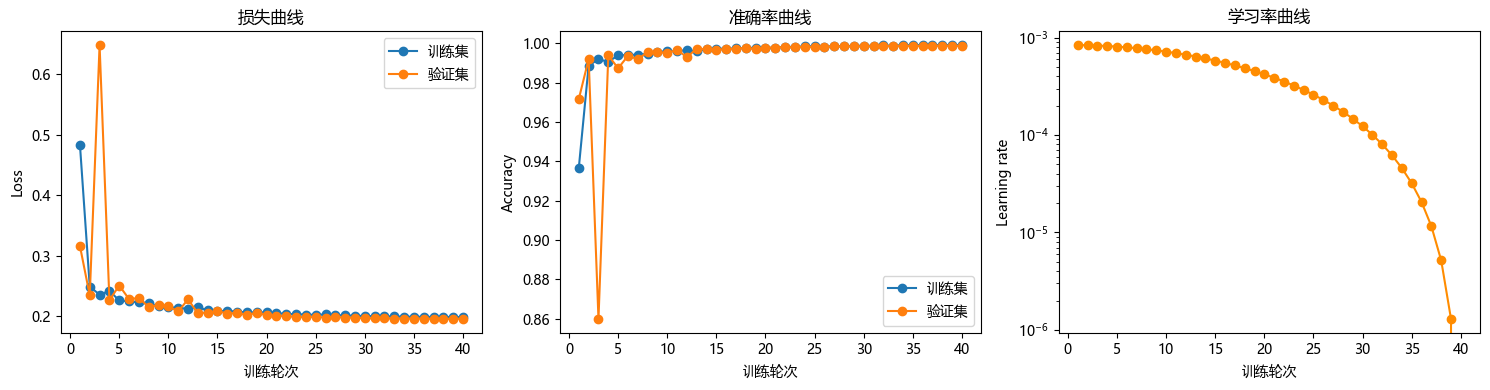

训练曲线已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\figures\training_curves.png
学习率曲线已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\figures\learning_rate_curve.png


In [12]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="训练集")
axes[0].plot(epochs, history["val_loss"], marker="o", label="验证集")
axes[0].set_title("损失曲线")
axes[0].set_xlabel("训练轮次")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs, history["train_accuracy"], marker="o", label="训练集")
axes[1].plot(epochs, history["val_accuracy"], marker="o", label="验证集")
axes[1].set_title("准确率曲线")
axes[1].set_xlabel("训练轮次")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

axes[2].plot(epochs, history.get("learning_rate", []), marker="o", color="darkorange")
axes[2].set_title("学习率曲线")
axes[2].set_xlabel("训练轮次")
axes[2].set_ylabel("Learning rate")
axes[2].set_yscale("log")

fig.tight_layout()
curve_path = FIGURE_DIR / "training_curves.png"
lr_curve_path = FIGURE_DIR / "learning_rate_curve.png"
fig.savefig(curve_path, dpi=160)
fig.savefig(lr_curve_path, dpi=160)
plt.show()
print(f"训练曲线已保存到：{curve_path}")
print(f"学习率曲线已保存到：{lr_curve_path}")

## 10. 验证集评估

下面加载验证集准确率最高的模型权重，在验证集上收集所有预测结果，并计算整体准确率与每个数字类别的 precision、recall、F1-score。

In [13]:
def collect_predictions(model, loader, device: str, cfg: ExperimentConfig):
    model.eval()
    image_batches = []
    true_batches = []
    pred_batches = []
    probability_batches = []

    with torch.no_grad():
        for images, labels in loader:
            with make_autocast_context(cfg, device):
                logits = model(images.to(device, non_blocking=True))
            probabilities = torch.softmax(logits, dim=1).cpu()
            predictions = probabilities.argmax(dim=1)
            image_batches.append(images.cpu())
            true_batches.append(labels.cpu())
            pred_batches.append(predictions.cpu())
            probability_batches.append(probabilities)

    return (
        torch.cat(image_batches),
        torch.cat(true_batches),
        torch.cat(pred_batches),
        torch.cat(probability_batches),
    )

eval_model, checkpoint_payload, loaded_model_name = load_model_from_checkpoint(
    checkpoint_path,
    cfg=config,
    device=DEVICE,
    return_payload=True,
)
eval_images, y_true, y_pred, y_prob = collect_predictions(eval_model, val_loader, DEVICE, config)

accuracy = accuracy_score(y_true.numpy(), y_pred.numpy())
report = classification_report(y_true.numpy(), y_pred.numpy(), digits=4, output_dict=True)
report_df = pd.DataFrame(report).transpose()
summary = {
    "accuracy": float(accuracy),
    "best_val_accuracy": float(history["best_val_accuracy"]),
    "validation_samples": int(len(y_true)),
    "validation_source": config.validation_source,
    "model_name": loaded_model_name,
    "batch_size": int(config.batch_size),
    "num_workers": int(config.num_workers),
    "use_amp": bool(config.use_amp and DEVICE == "cuda"),
    "allow_tf32": bool(config.allow_tf32 and DEVICE == "cuda"),
}
(LOG_DIR / "evaluation_summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"验证集模式：{config.validation_source}")
print(f"加载模型：{loaded_model_name}")
print(f"验证集准确率：{accuracy:.4f}")
display(report_df)

验证集模式：mixed
加载模型：medium_cnn
验证集准确率：0.9987


,precision,recall,f1-score,support
0,0.998892,0.998339,0.998616,3613.000000
1,0.998760,0.999007,0.998884,4030.000000
2,0.999424,0.999136,0.999280,3474.000000
3,0.998603,0.999161,0.998882,3577.000000
4,0.999141,0.998855,0.998998,3494.000000
5,0.999066,0.997514,0.998290,3218.000000
6,0.998846,0.998846,0.998846,3465.000000
7,0.997540,0.998632,0.998085,3654.000000
8,0.999111,0.999111,0.999111,3375.000000
9,0.998034,0.998595,0.998314,3558.000000


## 10.1 额外外部验证：多个 28×28 官方 holdout

mixed validation 来自当前训练数据源的 train split 固定切分。为了更接近老师可能提供的 28×28 私有普通数字图片，这里额外评估多个同格式官方 holdout：MNIST test、EMNIST Digits test、QMNIST test10k。它们都是 28×28 灰度手写数字、标签 0-9，不参与训练、不参与 HPO、不参与 checkpoint 选择，只用于最终额外泛化评估。


In [14]:
class DigitTargetAdapter(Dataset):
    def __init__(self, dataset, target_index: int | None = None):
        self.dataset = dataset
        self.target_index = target_index

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, target = self.dataset[index]
        if isinstance(target, torch.Tensor):
            target = target.flatten().tolist()
        if isinstance(target, np.ndarray):
            target = target.flatten().tolist()
        if isinstance(target, (tuple, list)):
            selected_index = 0 if self.target_index is None else self.target_index
            target = target[selected_index]
        return image, int(target)


def build_external_28x28_holdout_dataset(name: str, cfg: ExperimentConfig, transform):
    normalized_name = name.strip().lower()
    if normalized_name == "mnist_test":
        dataset = datasets.MNIST(root=str(cfg.data_dir), train=False, download=True, transform=transform)
        return "mnist_test", "Official MNIST test split; 28x28 grayscale digits; not used for training/HPO", dataset
    if normalized_name == "emnist_digits_test":
        emnist_transform = transforms.Compose([build_emnist_orientation_transform(), transform])
        dataset = datasets.EMNIST(root=str(cfg.data_dir), split="digits", train=False, download=True, transform=emnist_transform)
        return "emnist_digits_test", "Official EMNIST Digits test split; 28x28 grayscale digits; not used for training/HPO", dataset
    if normalized_name == "qmnist_test10k":
        dataset = datasets.QMNIST(root=str(cfg.data_dir), what="test10k", download=True, transform=transform)
        return "qmnist_test10k", "Official QMNIST test10k split; 28x28 grayscale digits; not used for training/HPO", DigitTargetAdapter(dataset)
    raise ValueError(f"未知 external holdout: {name}")

def make_external_holdout_loader(dataset, cfg: ExperimentConfig):
    return DataLoader(
        dataset,
        batch_size=cfg.external_validation_batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=cfg.pin_memory,
    )

def evaluate_external_28x28_holdouts(model, cfg: ExperimentConfig, transform):
    summaries = []
    reports = {}
    predictions_by_dataset = {}
    for holdout_name in cfg.external_holdout_names:
        dataset_key, description, holdout_dataset = build_external_28x28_holdout_dataset(holdout_name, cfg, transform)
        holdout_loader = make_external_holdout_loader(holdout_dataset, cfg)
        holdout_images, holdout_true, holdout_pred, holdout_prob = collect_predictions(model, holdout_loader, DEVICE, cfg)
        holdout_accuracy = accuracy_score(holdout_true.numpy(), holdout_pred.numpy())
        holdout_report = classification_report(holdout_true.numpy(), holdout_pred.numpy(), digits=4, output_dict=True)
        holdout_predictions = pd.DataFrame({
            "sample_index": np.arange(len(holdout_true)),
            "true_label": holdout_true.numpy(),
            "predicted_label": holdout_pred.numpy(),
            "confidence": holdout_prob.max(dim=1).values.numpy(),
        })
        holdout_predictions_path = PREDICTION_DIR / f"{dataset_key}_holdout_predictions.csv"
        holdout_predictions.to_csv(holdout_predictions_path, index=False, encoding="utf-8-sig")
        summary = {
            "dataset": dataset_key,
            "description": description,
            "samples": int(len(holdout_true)),
            "accuracy": float(holdout_accuracy),
            "macro_f1": float(holdout_report["macro avg"]["f1-score"]),
            "model_name": loaded_model_name,
            "checkpoint_path": str(checkpoint_path),
            "predictions_path": str(holdout_predictions_path),
        }
        summaries.append(summary)
        reports[dataset_key] = pd.DataFrame(holdout_report).transpose()
        predictions_by_dataset[dataset_key] = holdout_predictions
        print(f"{dataset_key}: samples={len(holdout_true)}, accuracy={holdout_accuracy:.4f}, macro_f1={summary['macro_f1']:.4f}")
    return summaries, reports, predictions_by_dataset

external_holdout_summaries = []
external_holdout_reports = {}
external_holdout_predictions = {}
if config.use_external_28x28_holdouts:
    external_holdout_summaries, external_holdout_reports, external_holdout_predictions = evaluate_external_28x28_holdouts(
        eval_model,
        config,
        base_transform,
    )
    external_holdout_summary_df = pd.DataFrame(external_holdout_summaries)
    external_holdout_summary_path = LOG_DIR / "external_validation_28x28_holdouts.csv"
    external_holdout_summary_json_path = LOG_DIR / "external_validation_28x28_holdouts.json"
    external_holdout_summary_df.to_csv(external_holdout_summary_path, index=False, encoding="utf-8-sig")
    external_holdout_summary_json_path.write_text(
        json.dumps(external_holdout_summaries, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    display(external_holdout_summary_df[["dataset", "samples", "accuracy", "macro_f1"]])
    print(f"多个 28×28 holdout 摘要已保存到：{external_holdout_summary_path}")
else:
    print("USE_EXTERNAL_28X28_HOLDOUTS=False：跳过额外 28×28 holdout 验证。")


mnist_test: samples=10000, accuracy=0.9973, macro_f1=0.9973
emnist_digits_test: samples=40000, accuracy=0.9973, macro_f1=0.9973
qmnist_test10k: samples=10000, accuracy=0.9973, macro_f1=0.9973


,dataset,samples,accuracy,macro_f1
0,mnist_test,10000,0.9973,0.997318
1,emnist_digits_test,40000,0.9973,0.997300
2,qmnist_test10k,10000,0.9973,0.997318


多个 28×28 holdout 摘要已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\logs\external_validation_28x28_holdouts.csv


## 11. 混淆矩阵

混淆矩阵用于观察哪些数字容易被混淆。矩阵的行是真实类别，列是预测类别；对角线越明显，说明分类越准确。

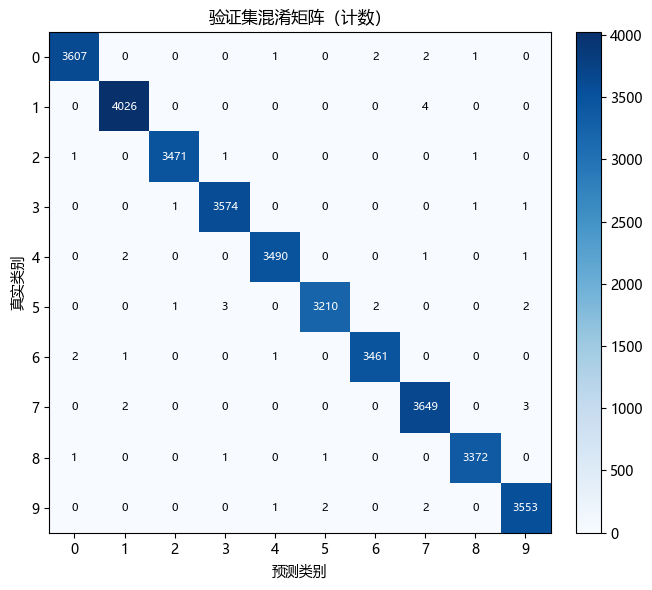

混淆矩阵图片已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\figures\confusion_matrix.png


In [15]:
labels = list(range(config.num_classes))
matrix = confusion_matrix(y_true.numpy(), y_pred.numpy(), labels=labels)
np.savetxt(FIGURE_DIR / "confusion_matrix.csv", matrix, delimiter=",", fmt="%d")

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(matrix, cmap="Blues")
ax.set_title("验证集混淆矩阵（计数）")
ax.set_xlabel("预测类别")
ax.set_ylabel("真实类别")
ax.set_xticks(np.arange(config.num_classes))
ax.set_yticks(np.arange(config.num_classes))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

threshold = matrix.max() / 2.0
for i in range(config.num_classes):
    for j in range(config.num_classes):
        ax.text(
            j,
            i,
            str(int(matrix[i, j])),
            ha="center",
            va="center",
            color="white" if matrix[i, j] > threshold else "black",
            fontsize=8,
        )

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
confusion_path = FIGURE_DIR / "confusion_matrix.png"
fig.savefig(confusion_path, dpi=160)
plt.show()
print(f"混淆矩阵图片已保存到：{confusion_path}")

## 12. 误分类样例分析

只看准确率不够，还需要观察模型错在哪里。下面展示若干个误分类样本，包括真实标签、预测标签和模型对预测类别的置信度。

验证集误分类数量：45 / 35458


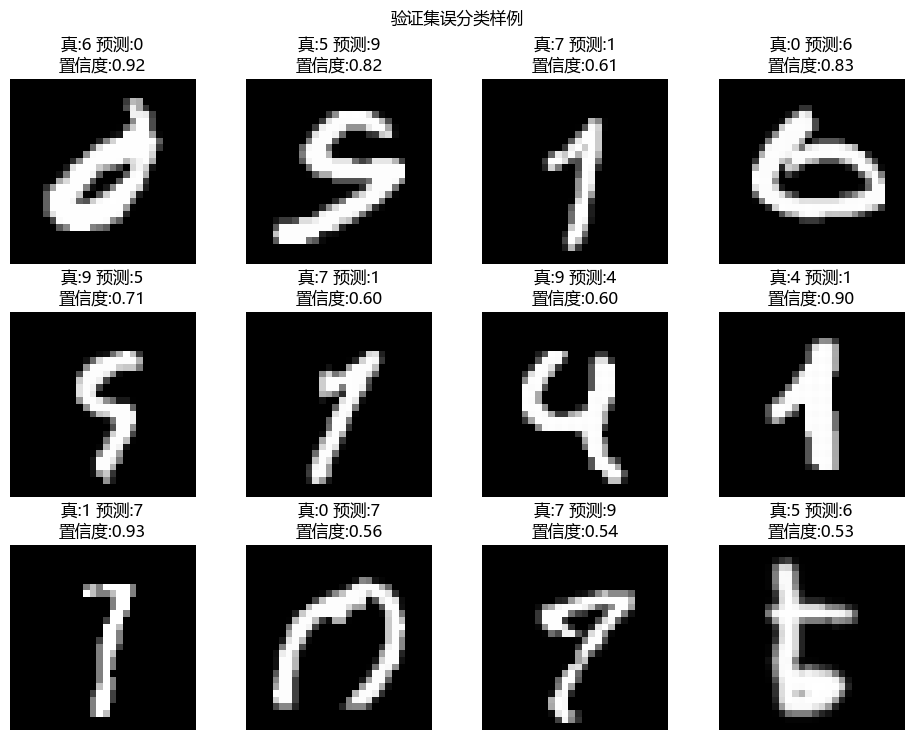

误分类样例图片已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\figures\misclassified_examples.png


In [16]:
wrong_indices = (y_true != y_pred).nonzero(as_tuple=False).flatten().tolist()
print(f"验证集误分类数量：{len(wrong_indices)} / {len(y_true)}")

if wrong_indices:
    sample_count = min(12, len(wrong_indices))
    selected = wrong_indices[:sample_count]
    cols = 4
    rows = int(np.ceil(sample_count / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 2.5))
    axes = np.array(axes).reshape(rows, cols)

    for axis, index in zip(axes.ravel(), selected):
        image = (eval_images[index] * 0.5 + 0.5).clamp(0, 1).squeeze(0).numpy()
        confidence = float(y_prob[index, y_pred[index]])
        axis.imshow(image, cmap="gray", vmin=0, vmax=1)
        axis.set_title(f"真:{int(y_true[index])} 预测:{int(y_pred[index])}\n置信度:{confidence:.2f}")
        axis.axis("off")

    for axis in axes.ravel()[sample_count:]:
        axis.axis("off")

    fig.suptitle("验证集误分类样例")
    fig.tight_layout()
    misclassified_path = FIGURE_DIR / "misclassified_examples.png"
    fig.savefig(misclassified_path, dpi=160)
    plt.show()
    print(f"误分类样例图片已保存到：{misclassified_path}")
else:
    print("验证集没有误分类样本。")

## 13. 导出预测结果

下面把验证集预测结果导出为 CSV，方便检查或作为预测导出格式示例。CSV 使用 `utf-8-sig` 编码，通常可以被 Excel 正确识别中文列名。

如果老师后续提供无标签图片目录，可以使用后面的 `predict_image_folder` 函数生成 `filename,prediction` 格式的预测文件。

In [17]:
validation_predictions = pd.DataFrame({
    "样本序号": np.arange(len(y_true)),
    "真实标签": y_true.numpy(),
    "预测标签": y_pred.numpy(),
    "预测置信度": y_prob.max(dim=1).values.numpy(),
})
validation_csv_path = PREDICTION_DIR / "validation_predictions.csv"
validation_predictions.to_csv(validation_csv_path, index=False, encoding="utf-8-sig")
display(validation_predictions.head())
print(f"验证集预测结果已保存到：{validation_csv_path}")

c:\Users\claredz\anaconda3\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,样本序号,真实标签,预测标签,预测置信度
0,0,2,2,0.984375
1,1,8,8,0.973633
2,2,7,7,0.979004
3,3,9,9,0.973633
4,4,2,2,0.962891


验证集预测结果已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\predictions\validation_predictions.csv


In [18]:
def apply_tta_transform(image_tensor: torch.Tensor) -> torch.Tensor:
    raw = (image_tensor * NORMALIZE_STD[0] + NORMALIZE_MEAN[0]).clamp(0, 1)
    angle = float(np.random.uniform(-8, 8))
    max_shift = 2
    translate = [int(np.random.randint(-max_shift, max_shift + 1)), int(np.random.randint(-max_shift, max_shift + 1))]
    scale = float(np.random.uniform(0.95, 1.05))
    shear = [float(np.random.uniform(-3, 3)), 0.0]
    augmented = TF.affine(
        raw,
        angle=angle,
        translate=translate,
        scale=scale,
        shear=shear,
        interpolation=InterpolationMode.BILINEAR,
        fill=0,
    )
    return (augmented - NORMALIZE_MEAN[0]) / NORMALIZE_STD[0]

def predict_with_tta(model, image_tensor: torch.Tensor, n: int = 8, cfg: ExperimentConfig = config):
    model.eval()
    samples = [image_tensor]
    for _ in range(max(0, n - 1)):
        samples.append(apply_tta_transform(image_tensor))
    batch = torch.stack(samples).to(DEVICE, non_blocking=True)
    with torch.no_grad(), make_autocast_context(cfg, DEVICE):
        mean_logits = model(batch).mean(dim=0)
        probabilities = torch.softmax(mean_logits, dim=0).cpu()
    predicted_label = int(probabilities.argmax().item())
    confidence = float(probabilities[predicted_label].item())
    return predicted_label, confidence, probabilities

class ImageFolderForPrediction(Dataset):
    def __init__(self, image_dir: Path, image_size: int = 28):
        self.image_dir = Path(image_dir)
        self.image_paths = sorted(
            path for path in self.image_dir.iterdir()
            if path.suffix.lower() in SUPPORTED_IMAGE_SUFFIXES
        )
        if not self.image_paths:
            raise ValueError(f"目录 {self.image_dir} 中没有找到图片文件。")
        self.image_size = image_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        tensor = preprocess_digit_image(image_path, image_size=self.image_size, invert="auto")
        return tensor, image_path.name

def predict_image_folder(
    image_dir: str | Path,
    output_csv: str | Path | None = None,
    checkpoint: str | Path | None = None,
    use_tta: bool | None = None,
    tta_n: int | None = None,
):
    image_dataset = ImageFolderForPrediction(Path(image_dir), image_size=config.image_size)
    checkpoint = checkpoint_path if checkpoint is None else Path(checkpoint)
    output_csv = PREDICTION_DIR / "unlabeled_predictions.csv" if output_csv is None else Path(output_csv)
    use_tta = config.use_tta if use_tta is None else use_tta
    tta_n = config.tta_n if tta_n is None else tta_n
    predictor, _, loaded_model_name = load_model_from_checkpoint(checkpoint, cfg=config, device=DEVICE, return_payload=True)

    rows = []
    if use_tta:
        for image_tensor, filename in image_dataset:
            predicted_label, confidence, _ = predict_with_tta(predictor, image_tensor, n=tta_n, cfg=config)
            rows.append({"filename": filename, "predicted_label": predicted_label, "confidence": confidence})
    else:
        image_loader = DataLoader(
            image_dataset,
            batch_size=config.batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=config.pin_memory,
        )
        with torch.no_grad():
            for images, filenames in image_loader:
                with make_autocast_context(config, DEVICE):
                    logits = predictor(images.to(DEVICE, non_blocking=True))
                probabilities = torch.softmax(logits, dim=1).cpu()
                predictions = probabilities.argmax(dim=1).tolist()
                confidences = probabilities.max(dim=1).values.tolist()
                for filename, prediction, confidence in zip(filenames, predictions, confidences):
                    rows.append({"filename": filename, "predicted_label": prediction, "confidence": confidence})

    output_csv.parent.mkdir(parents=True, exist_ok=True)
    prediction_df = pd.DataFrame(rows)
    prediction_df.to_csv(output_csv, index=False, encoding="utf-8-sig")
    low_confidence_df = prediction_df[prediction_df["confidence"] < LOW_CONFIDENCE_THRESHOLD]
    if len(low_confidence_df) > 0:
        low_path = output_csv.parent / "low_confidence_samples.csv"
        low_confidence_df.to_csv(low_path, index=False, encoding="utf-8-sig")
        print(f"低置信度样本已保存到：{low_path}")
    print(f"无标签图片预测结果已保存到：{output_csv}，模型={loaded_model_name}，TTA={'开启' if use_tta else '关闭'}")
    return prediction_df

# 使用示例：取消下一行注释，并把路径改成老师提供的无标签测试图片目录。
# predict_image_folder("path/to/unlabeled_images")

In [19]:
# =========================
# 14. 考试模式：现场快速 fine-tune / 预测
# =========================

def resolve_project_path(path_like: str | Path) -> Path:
    path = Path(path_like)
    return path if path.is_absolute() else PROJECT_ROOT / path

def list_exam_train_samples(train_dir: str | Path):
    train_dir = resolve_project_path(train_dir)
    image_paths, labels = [], []
    if not train_dir.exists():
        return image_paths, labels
    for label in range(config.num_classes):
        class_dir = train_dir / str(label)
        if not class_dir.exists():
            continue
        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() in SUPPORTED_IMAGE_SUFFIXES:
                image_paths.append(image_path)
                labels.append(label)
    return image_paths, labels

def list_exam_test_images(test_dir: str | Path):
    test_dir = resolve_project_path(test_dir)
    if not test_dir.exists():
        return []
    return sorted(path for path in test_dir.iterdir() if path.suffix.lower() in SUPPORTED_IMAGE_SUFFIXES)

def augment_normalized_digit_tensor(image_tensor, rotation_degrees=8, translate_ratio=0.08, scale_min=0.95, scale_max=1.05, shear_degrees=3):
    raw = (image_tensor * NORMALIZE_STD[0] + NORMALIZE_MEAN[0]).clamp(0, 1)
    max_shift = max(1, int(round(config.image_size * translate_ratio)))
    angle = float(np.random.uniform(-rotation_degrees, rotation_degrees))
    translate = [int(np.random.randint(-max_shift, max_shift + 1)), int(np.random.randint(-max_shift, max_shift + 1))]
    scale = float(np.random.uniform(scale_min, scale_max))
    shear = [float(np.random.uniform(-shear_degrees, shear_degrees)), 0.0]
    augmented = TF.affine(raw, angle=angle, translate=translate, scale=scale, shear=shear, interpolation=InterpolationMode.BILINEAR, fill=0)
    return (augmented - NORMALIZE_MEAN[0]) / NORMALIZE_STD[0]

class ExamLabeledDataset(Dataset):
    def __init__(self, image_paths, labels, image_size: int = 28, augment: bool = False, aug_params: dict | None = None):
        self.image_paths = [Path(path) for path in image_paths]
        self.labels = [int(label) for label in labels]
        self.image_size = image_size
        self.augment = augment
        self.aug_params = aug_params or {}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        tensor = preprocess_digit_image(self.image_paths[index], image_size=self.image_size, invert="auto")
        if self.augment:
            tensor = augment_normalized_digit_tensor(tensor, **self.aug_params)
        return tensor, self.labels[index]

def split_exam_train_val(image_paths, labels, seed: int, val_ratio: float = 0.2):
    if len(image_paths) < 5:
        return image_paths, labels, image_paths, labels
    indices = np.random.default_rng(seed).permutation(len(image_paths)).tolist()
    val_size = max(1, int(len(indices) * val_ratio))
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]
    train_paths = [image_paths[i] for i in train_indices]
    train_labels = [labels[i] for i in train_indices]
    val_paths = [image_paths[i] for i in val_indices]
    val_labels = [labels[i] for i in val_indices]
    return train_paths, train_labels, val_paths, val_labels

def make_exam_loaders(train_paths, train_labels, val_paths, val_labels, batch_size: int, aug_params: dict | None = None):
    train_dataset_exam = ExamLabeledDataset(train_paths, train_labels, config.image_size, augment=True, aug_params=aug_params)
    val_dataset_exam = ExamLabeledDataset(val_paths, val_labels, config.image_size, augment=False)
    train_loader_exam = DataLoader(train_dataset_exam, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=config.pin_memory)
    val_loader_exam = DataLoader(val_dataset_exam, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=config.pin_memory)
    return train_loader_exam, val_loader_exam

def set_feature_extractor_trainable(model: nn.Module, trainable: bool) -> bool:
    if not hasattr(model, "features"):
        return False
    for parameter in model.features.parameters():
        parameter.requires_grad = trainable
    return True

def default_exam_params():
    return {
        "learning_rate": EXAM_FINE_TUNE_LR,
        "weight_decay": config.weight_decay,
        "dropout": config.dropout,
        "rotation_degrees": 8,
        "translate_ratio": 0.06,
        "scale_min": 0.95,
        "scale_max": 1.05,
        "shear_degrees": 3,
    }

def run_exam_fast_hpo(train_paths, train_labels, val_paths, val_labels, base_checkpoint: Path):
    if not EXAM_FAST_HPO or len(train_paths) == 0:
        return default_exam_params()
    try:
        import optuna
    except ImportError:
        print("未安装 optuna，跳过考试快速 HPO。")
        return default_exam_params()

    def objective(trial):
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
            "dropout": trial.suggest_float("dropout", 0.10, 0.40),
            "rotation_degrees": trial.suggest_float("rotation_degrees", 0, 10),
            "translate_ratio": trial.suggest_float("translate_ratio", 0.0, 0.10),
            "scale_min": trial.suggest_float("scale_min", 0.90, 0.98),
            "scale_max": trial.suggest_float("scale_max", 1.02, 1.10),
            "shear_degrees": trial.suggest_float("shear_degrees", 0, 5),
        }
        trial_model, _, loaded_model_name = load_model_from_checkpoint(
            base_checkpoint,
            cfg=config,
            device=DEVICE,
            dropout=params["dropout"],
            return_payload=True,
        )
        if EXAM_FREEZE_FEATURE_EXTRACTOR:
            if set_feature_extractor_trainable(trial_model, trainable=False):
                print("考试快速 HPO：已冻结特征提取层。")
            else:
                print("考试快速 HPO：当前模型没有 features 属性，跳过冻结。")
        train_loader_exam, val_loader_exam = make_exam_loaders(
            train_paths,
            train_labels,
            val_paths,
            val_labels,
            batch_size=min(config.batch_size, max(1, len(train_paths))),
            aug_params={key: params[key] for key in ["rotation_degrees", "translate_ratio", "scale_min", "scale_max", "shear_degrees"]},
        )
        trial_config = replace(
            config,
            model_name=loaded_model_name,
            learning_rate=params["learning_rate"],
            weight_decay=params["weight_decay"],
            dropout=params["dropout"],
            optimizer_type="AdamW",
            scheduler_type="none",
            epochs=EXAM_HPO_EPOCHS,
        )
        optimizer = torch.optim.AdamW(
            (parameter for parameter in trial_model.parameters() if parameter.requires_grad),
            lr=params["learning_rate"],
            weight_decay=params["weight_decay"],
        )
        criterion = nn.CrossEntropyLoss(label_smoothing=trial_config.label_smoothing)
        scaler = make_grad_scaler(trial_config, DEVICE)
        best_acc = 0.0
        for _ in range(EXAM_HPO_EPOCHS):
            run_epoch(trial_model, train_loader_exam, criterion, DEVICE, optimizer=optimizer, scaler=scaler, cfg=trial_config)
            metrics = run_epoch(trial_model, val_loader_exam, criterion, DEVICE, optimizer=None, cfg=trial_config)
            best_acc = max(best_acc, metrics["accuracy"])
        return best_acc

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=config.seed + 100))
    study.optimize(objective, n_trials=EXAM_HPO_N_TRIALS)
    exam_best_params_path = HPO_DIR / "exam_best_params.json"
    exam_best_params_path.write_text(json.dumps(study.best_params, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"考试快速 HPO 最佳验证准确率：{study.best_value:.4f}")
    print(f"考试快速 HPO 最佳参数已保存到：{exam_best_params_path}")
    return study.best_params

def run_exam_mode():
    train_paths, train_labels = list_exam_train_samples(EXAM_TRAIN_DIR)
    test_paths = list_exam_test_images(EXAM_TEST_DIR)
    base_checkpoint = resolve_project_path(EXAM_CHECKPOINT_PATH)
    exam_checkpoint = CHECKPOINT_DIR / "exam_best_model_state.pt"

    if EXAM_USE_PRETRAINED_CHECKPOINT and base_checkpoint.exists():
        active_checkpoint = base_checkpoint
        print(f"考试模式：加载已有 checkpoint：{active_checkpoint}")
    else:
        active_checkpoint = checkpoint_path if "checkpoint_path" in globals() else CHECKPOINT_DIR / "best_model_state.pt"
        print(f"考试模式：未找到指定 checkpoint，改用当前训练 checkpoint：{active_checkpoint}")

    if train_paths:
        print(f"考试模式：检测到 {len(train_paths)} 张有标签训练图片，开始快速 fine-tune。")
        train_paths_split, train_labels_split, val_paths_split, val_labels_split = split_exam_train_val(train_paths, train_labels, config.seed + 200)
        exam_params = run_exam_fast_hpo(train_paths_split, train_labels_split, val_paths_split, val_labels_split, active_checkpoint)
        exam_model, _, exam_model_name = load_model_from_checkpoint(
            active_checkpoint,
            cfg=config,
            device=DEVICE,
            dropout=float(exam_params.get("dropout", config.dropout)),
            return_payload=True,
        )
        if EXAM_FREEZE_FEATURE_EXTRACTOR:
            if set_feature_extractor_trainable(exam_model, trainable=False):
                print("考试 fine-tune：已冻结特征提取层。")
            else:
                print("考试 fine-tune：当前模型没有 features 属性，跳过冻结。")
        train_loader_exam, val_loader_exam = make_exam_loaders(
            train_paths_split,
            train_labels_split,
            val_paths_split,
            val_labels_split,
            batch_size=min(config.batch_size, max(1, len(train_paths_split))),
            aug_params={key: exam_params[key] for key in ["rotation_degrees", "translate_ratio", "scale_min", "scale_max", "shear_degrees"] if key in exam_params},
        )
        exam_config = replace(
            config,
            model_name=exam_model_name,
            epochs=EXAM_FINE_TUNE_EPOCHS,
            learning_rate=float(exam_params.get("learning_rate", EXAM_FINE_TUNE_LR)),
            weight_decay=float(exam_params.get("weight_decay", config.weight_decay)),
            dropout=float(exam_params.get("dropout", config.dropout)),
            optimizer_type="AdamW",
            scheduler_type="ReduceLROnPlateau",
            early_stopping_patience=2,
        )
        exam_history, active_checkpoint = train_model(exam_model, train_loader_exam, val_loader_exam, exam_config, checkpoint_path=exam_checkpoint)
        print(f"考试 fine-tune 完成，最佳模型保存到：{active_checkpoint}")
    else:
        print("考试模式：未检测到有标签训练数据，自动跳过 fine-tuning。")

    if test_paths:
        print(f"考试模式：检测到 {len(test_paths)} 张无标签测试图片，开始预测。")
        prediction_df = predict_image_folder(
            EXAM_TEST_DIR,
            output_csv=resolve_project_path(EXAM_OUTPUT_CSV),
            checkpoint=active_checkpoint,
            use_tta=USE_TTA,
            tta_n=TTA_N,
        )
        display(prediction_df.head())
        return prediction_df
    print("考试模式：未检测到无标签测试图片，跳过预测 CSV 导出。")
    return None

if EXAM_MODE:
    exam_predictions = run_exam_mode()
else:
    print("EXAM_MODE=False：跳过考试模式。需要现场适配老师数据时，把 EXAM_MODE 改为 True 后运行本节。")

# =========================
# 15. 实验对比摘要
# =========================

def datasets_used_from_config(cfg: ExperimentConfig) -> str:
    names = []
    if cfg.use_mnist:
        names.append("MNIST")
    if cfg.use_emnist_digits:
        names.append("EMNIST Digits")
    if cfg.use_usps:
        names.append("USPS")
    if cfg.use_qmnist:
        names.append("QMNIST")
    return " + ".join(names)

def safe_float(value, default: float = float("nan")) -> float:
    if value is None:
        return default
    try:
        return float(value)
    except (TypeError, ValueError):
        return default

def record_experiment_result(experiment_name: str, cfg: ExperimentConfig, history: dict, checkpoint_path: Path):
    return {
        "experiment_name": experiment_name,
        "model_name": normalize_model_name(cfg.model_name),
        "num_parameters": int(history.get("num_parameters", 0)),
        "datasets_used": datasets_used_from_config(cfg),
        "validation_source": cfg.validation_source,
        "val_accuracy": safe_float(history.get("best_val_accuracy")),
        "val_loss": safe_float(history.get("best_val_loss")),
        "best_epoch": int(history.get("best_epoch", 0)),
        "checkpoint_path": str(checkpoint_path),
        "batch_size": int(cfg.batch_size),
        "num_workers": int(cfg.num_workers),
        "pin_memory": bool(cfg.pin_memory),
        "use_amp": bool(cfg.use_amp and DEVICE == "cuda"),
        "allow_tf32": bool(cfg.allow_tf32 and DEVICE == "cuda"),
        "label_smoothing": float(cfg.label_smoothing),
        "optimizer_type": cfg.optimizer_type,
        "scheduler_type": cfg.scheduler_type,
        "total_training_time_sec": safe_float(history.get("total_training_time_sec")),
        "average_train_samples_per_sec": safe_float(history.get("average_train_samples_per_sec")),
        "mnist_test_holdout_accuracy": safe_float(next((item.get("accuracy") for item in globals().get("external_holdout_summaries", []) if item.get("dataset") == "mnist_test"), np.nan)),
        "emnist_digits_test_holdout_accuracy": safe_float(next((item.get("accuracy") for item in globals().get("external_holdout_summaries", []) if item.get("dataset") == "emnist_digits_test"), np.nan)),
        "qmnist_test10k_holdout_accuracy": safe_float(next((item.get("accuracy") for item in globals().get("external_holdout_summaries", []) if item.get("dataset") == "qmnist_test10k"), np.nan)),
        "use_tta": bool(cfg.use_tta),
    }

experiment_summary = pd.DataFrame([
    record_experiment_result("current_run", config, history, checkpoint_path)
])
experiment_summary_path = LOG_DIR / "experiment_summary.csv"
experiment_summary.to_csv(experiment_summary_path, index=False, encoding="utf-8-sig")
display(experiment_summary)
print(f"实验摘要已保存到：{experiment_summary_path}")
print("可手动重复运行并记录：small_cnn vs medium_cnn、BATCH_SIZE 256/512/1024、NUM_WORKERS 0/4、TTA on/off。")

EXAM_MODE=False：跳过考试模式。需要现场适配老师数据时，把 EXAM_MODE 改为 True 后运行本节。

,experiment_name,model_name,num_parameters,datasets_used,validation_source,val_accuracy,val_loss,best_epoch,checkpoint_path,batch_size,...,allow_tf32,label_smoothing,optimizer_type,scheduler_type,total_training_time_sec,average_train_samples_per_sec,mnist_test_holdout_accuracy,emnist_digits_test_holdout_accuracy,qmnist_test10k_holdout_accuracy,use_tta
0,current_run,medium_cnn,251562,MNIST + EMNIST Digits + USPS + QMNIST,mixed,0.998731,0.195924,37,e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\che...,512,...,True,0.03,AdamW,CosineAnnealingLR,628.877597,12813.702211,0.9973,0.9973,0.9973,True


实验摘要已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\logs\experiment_summary.csv
可手动重复运行并记录：small_cnn vs medium_cnn、BATCH_SIZE 256/512/1024、NUM_WORKERS 0/4、TTA on/off。


## 16. 实验对比与使用说明

### 当前推荐默认配置

```python
MODEL_NAME = "medium_cnn"
BATCH_SIZE = 512          # 显存足够可试 1024；不稳定退回 256
NUM_WORKERS = 4           # Windows/Jupyter 卡住时改回 0
OPTIMIZER_TYPE = "AdamW"
WEIGHT_DECAY = 1e-4
DROPOUT = 0.30
LABEL_SMOOTHING = 0.03
EPOCHS = 25
USE_AMP = DEVICE == "cuda"
ALLOW_TF32 = DEVICE == "cuda"
RUN_HPO = False
USE_TTA = True
TTA_N = 8
```

这些默认值的目标是：用 `MediumCNN` 增加合理计算量，用大 batch、AMP、TF32、cuDNN benchmark、pin memory 和 DataLoader worker 提高吞吐，同时用 AdamW、label smoothing、增强和 TTA 维持或提升 mixed validation / 测试准确率。

### 实验对比建议

notebook 已在 `outputs_submission/logs/experiment_summary.csv` 中记录当前运行结果。为了比较不同策略，可以手动改配置后分别从头运行，并把结果追加或另存：

| experiment_name | 推荐配置 | 目的 |
|---|---|---|
| SmallCNN baseline | `MODEL_NAME="small_cnn"`, `BATCH_SIZE=256`, `RUN_HPO=False` | 复现轻量 baseline |
| MediumCNN default | `MODEL_NAME="medium_cnn"`, `BATCH_SIZE=512`, `USE_AMP=True` | 当前推荐强训练配置 |
| High-throughput trial | `BATCH_SIZE=1024` | 显存足够时测试吞吐和 GPU 利用率 |
| Stable Windows/Jupyter | `NUM_WORKERS=0` | 多进程 DataLoader 卡住时使用 |
| Full mixed training | MNIST + EMNIST Digits + USPS + QMNIST，`VALIDATION_SOURCE="mixed"` | 最完整地观察跨来源泛化 |
| TTA on/off | 固定训练配置，只切换 `USE_TTA=True/False` | 比较测试时增强对现场图片预测的影响 |

### 如何普通训练

1. 设置 `EXAM_MODE=False`。
2. 默认保持 `MODEL_NAME="medium_cnn"`, `BATCH_SIZE=512`, `RUN_HPO=False`。
3. 开启 MNIST、EMNIST Digits、USPS、QMNIST，并保持 `VALIDATION_SOURCE="mixed"`，可以观察跨来源泛化。
4. 如果只想和原始 MNIST baseline 对比，把 `VALIDATION_SOURCE="mnist_validation"`；此时验证集只来自 MNIST，外部数据全部进入训练集。
5. 如果 notebook 卡在 batch 预览或训练第一步，通常是 Windows/Jupyter 的 DataLoader 多进程问题，把 `NUM_WORKERS=0` 后重跑数据加载单元。
6. 从上到下运行全部单元格。正式训练会保存验证集表现最好的 checkpoint，并在 history 中记录耗时和 samples/sec。

### 如何自动调参

1. 设置 `RUN_HPO=True`。
2. 如果希望自动把最佳参数用于正式训练，设置 `APPLY_BEST_HPO_PARAMS=True`。
3. 可按时间调整 `HPO_N_TRIALS` 和 `HPO_EPOCHS`。
4. HPO 搜索 `model_name`、`batch_size`、学习率、weight decay、dropout、增强强度和 scheduler；正式训练会从 scratch 使用 best params 重新训练。
5. 输出文件：
   - `outputs_submission/hpo/best_params.json`
   - `outputs_submission/hpo/optuna_trials.csv`

### 如何使用考试模式

考试模式用于老师允许现场训练、调参或预测时快速适配数据分布。不要在无标签测试集上训练；本 notebook 默认没有开启伪标签。

1. 有标签训练数据按 ImageFolder 结构放置：

```text
exam_data/train/
    0/
    1/
    2/
    ...
    9/
```

2. 无标签测试图片放置：

```text
exam_data/test/
    xxx.png
    yyy.jpg
```

3. 设置：

```python
EXAM_MODE = True
EXAM_USE_PRETRAINED_CHECKPOINT = True
EXAM_FAST_HPO = True
EXAM_HPO_N_TRIALS = 5
EXAM_HPO_EPOCHS = 2
EXAM_FINE_TUNE_EPOCHS = 3
USE_TTA = True
```

4. 从上到下运行 notebook，或至少运行到“考试模式”单元。三种情况都会自动处理：
   - 只有 `exam_data/train/`：加载 `best_model_state.pt` 后 fine-tune，并保存考试模型；
   - 只有 `exam_data/test/`：不训练，直接预处理 + AMP/TTA 预测；
   - 两者都有：先 fine-tune，再对测试图片预测。

### 关键输出位置

- 最佳普通训练模型：`outputs_submission/checkpoints/best_model_state.pt`
- 考试 fine-tune 模型：`outputs_submission/checkpoints/exam_best_model_state.pt`
- 训练记录：`outputs_submission/logs/history.json`
- 实验对比表：`outputs_submission/logs/experiment_summary.csv`
- 评估摘要：`outputs_submission/logs/evaluation_summary.json`
- 验证集预测：`outputs_submission/predictions/validation_predictions.csv`
- 考试预测：`outputs_submission/predictions/exam_predictions.csv`
- 低置信度样本：`outputs_submission/predictions/low_confidence_samples.csv`

### GPU 利用率说明

`28×28` 灰度图分类任务本身很轻，即使启用 `MediumCNN + BATCH_SIZE=512 + AMP/TF32`，也不保证 Windows 任务管理器长期稳定显示 90%。更可靠的优化目标是提升 samples/sec、减少每 epoch 时间、增加显存/计算利用，并保持 mixed validation 准确率接近或超过旧 baseline。